# 02 - Persuasion Outcome Analysis

Analysis of persuasion outcomes by stance, condition, LLM, and dilemma type.

In [1]:
source("00_setup.R")

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
“package ‘jsonlite’ was built under R version 4.3.3”

Attaching package: ‘jsonlite’


The following object is masked from ‘package:purrr’:

    flatten


Loading pre-processed data...

Loaded: 24 participants, 192 observations, 96 chat observations


=== Data Loaded ===

Participants: 24

Total observations (data_long): 192

Chat observations (data_chat_analysis): 96



## Overall Outcomes

outcome,n,pct
<chr>,<int>,<dbl>
Backfired,16,16.7
Moved toward AI,28,29.2
No Change,52,54.2


Saved: figures/01_overall_outcomes.png



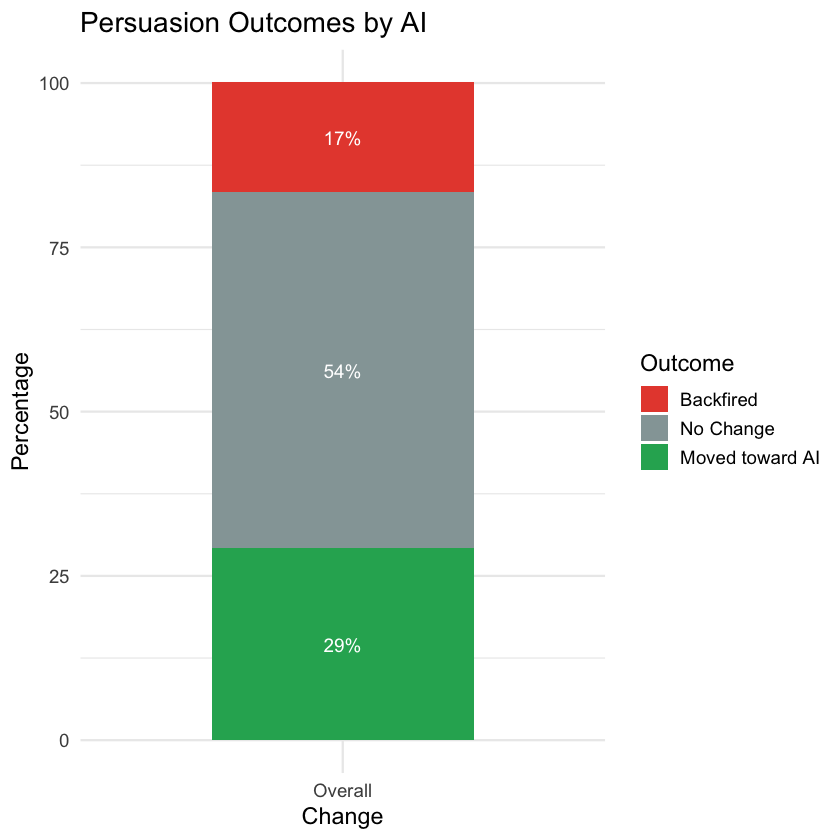

In [2]:
# Overall outcome
overall_outcomes_full <- data_chat_analysis %>%
  count(outcome) %>%
  mutate(pct = round(n / sum(n) * 100, 1))

overall_outcomes_full

# Stacked bar plot: Overall outcome breakdown 
plot_data <- overall_outcomes_full %>%
  mutate(outcome = factor(outcome, levels = c("Backfired", "No Change", "Moved toward AI")))

p1 <- ggplot(plot_data, aes(x = "Overall", y = pct, fill = outcome )) +
  geom_col(width = 0.6) +
  geom_text(aes(label = ifelse(pct >= 5, sprintf("%.0f%%", pct), "")), 
            position = position_stack(vjust = 0.5), size = 4, color = "white") +
  scale_fill_manual(values = c(
    "Moved toward AI" = "#27AE60",
    "No Change" = "#95A5A6",
    "Backfired" = "#E74C3C"
  )) +
  labs(
    title = "Persuasion Outcomes by AI",
    x = "Change",
    y = "Percentage",
    fill = "Outcome"
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "right")

p1
dir.create("figures", showWarnings = FALSE)
ggsave("figures/01_overall_outcomes.png", p1, width = 8, height = 6, dpi = 300)
message("Saved: figures/01_overall_outcomes.png")

Overall Statistics:



# A tibble: 1 × 7
      n mean_movement sd_movement se_movement mean_abs_change sd_abs_change
  <int>         <dbl>       <dbl>       <dbl>           <dbl>         <dbl>
1    96         0.344        1.77       0.181            1.05          1.46
# ℹ 1 more variable: se_abs_change <dbl>



Mean change magnitude by outcome:



# A tibble: 2 × 5
  outcome             n mean_change sd_change se_change
  <fct>           <int>       <dbl>     <dbl>     <dbl>
1 Backfired          16        2.12      1.31     0.328
2 Moved toward AI    28        2.39      1.37     0.259

--- Binomial Test: Direction of Change ---
Moved toward AI: 28 (63.6%)
Backfired: 16 (36.4%)
Total who changed: 44

H0: p = 0.5 (equal chance of either direction)
Observed proportion: 63.6%
p-value (one-tailed): 0.0481 *
95% CI: [50.1%, 100%]



Saved: figures/00a_outcome_direction.png



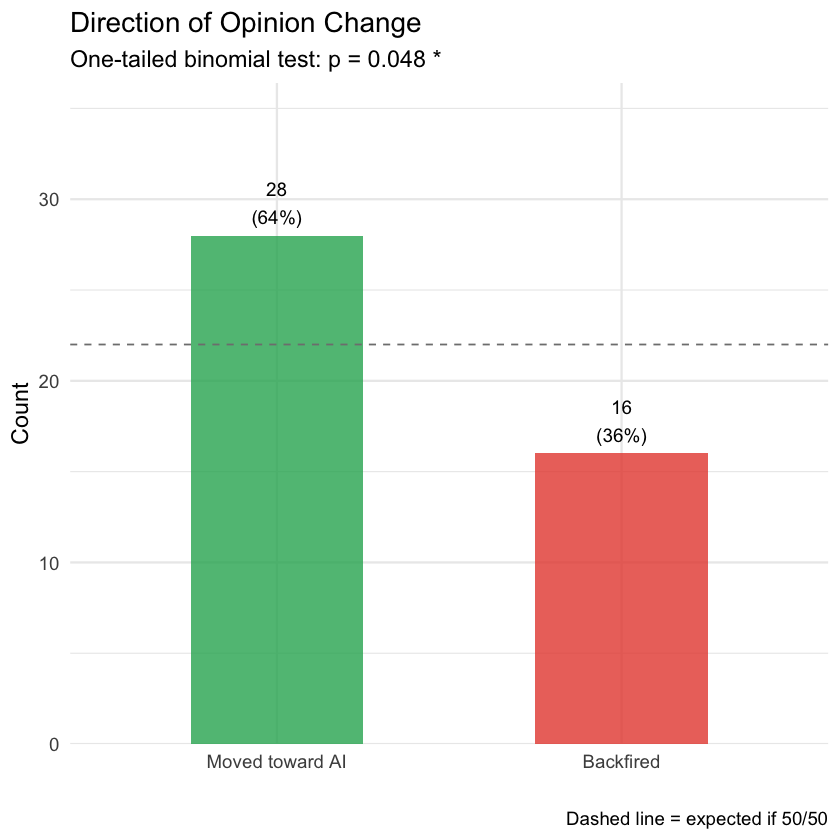

Saved: figures/00b_change_distribution.png



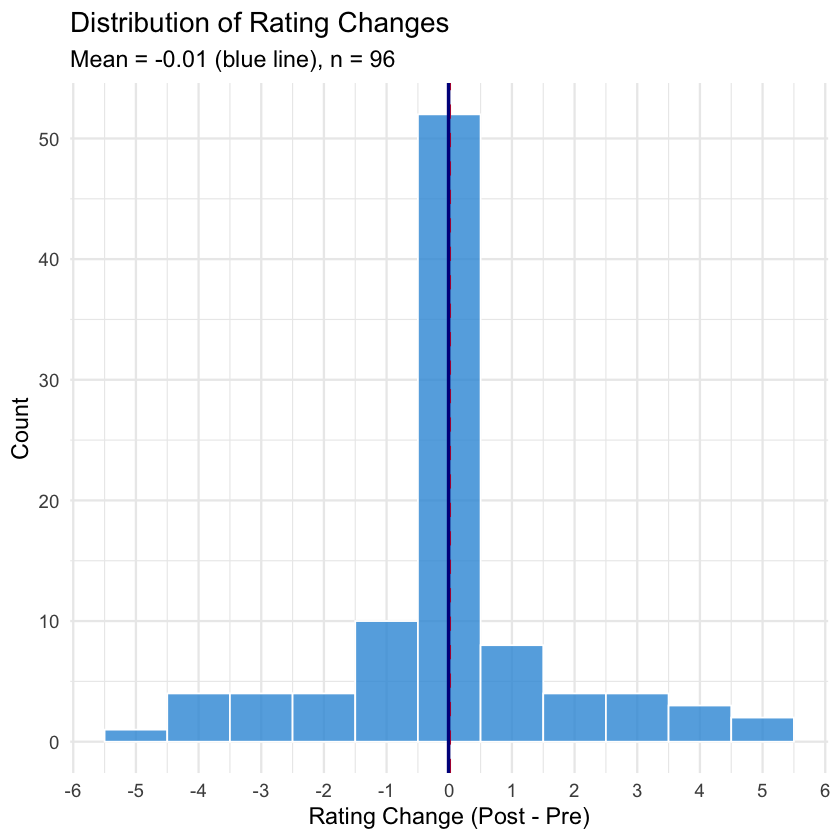

In [3]:
# Overall mean change visualization
overall_stats <- data_chat_analysis %>%
  mutate(
    movement_toward_ai = case_when(
      outcome == "Moved toward AI" ~ abs(rating_change),
      outcome == "Backfired" ~ -abs(rating_change),
      TRUE ~ 0
    )
  ) %>%
  summarise(
    n = n(),
    mean_movement = mean(movement_toward_ai),
    sd_movement = sd(movement_toward_ai),
    se_movement = sd_movement / sqrt(n),
    mean_abs_change = mean(abs(rating_change)),
    sd_abs_change = sd(abs(rating_change)),
    se_abs_change = sd_abs_change / sqrt(n)
  )

message("Overall Statistics:")
print(overall_stats)

# Mean change by outcome direction (excluding no change)
outcome_data <- data_chat_analysis %>%
  filter(outcome %in% c("Moved toward AI", "Backfired")) %>%
  mutate(abs_change = abs(rating_change))

outcome_means <- outcome_data %>%
  group_by(outcome) %>%
  summarise(
    n = n(),
    mean_change = mean(abs_change),
    sd_change = sd(abs_change),
    se_change = sd_change / sqrt(n),
    .groups = "drop"
  ) %>%
  mutate(outcome = factor(outcome, levels = c("Moved toward AI", "Backfired")))

message("\nMean change magnitude by outcome:")
print(outcome_means)

# Binomial test: Are people more likely to move toward AI than backfire?
n_moved_toward <- sum(outcome_data$outcome == "Moved toward AI")
n_backfired <- sum(outcome_data$outcome == "Backfired")
n_total <- n_moved_toward + n_backfired
prop_toward <- n_moved_toward / n_total

binom_result <- binom.test(n_moved_toward, n_total, p = 0.5, alternative = "greater")

cat("\n")
cat("--- Binomial Test: Direction of Change ---\n")
cat(sprintf("Moved toward AI: %d (%.1f%%)\n", n_moved_toward, prop_toward * 100))
cat(sprintf("Backfired: %d (%.1f%%)\n", n_backfired, (1 - prop_toward) * 100))
cat(sprintf("Total who changed: %d\n", n_total))
cat(sprintf("\nH0: p = 0.5 (equal chance of either direction)\n"))
cat(sprintf("Observed proportion: %.1f%%\n", prop_toward * 100))
cat(sprintf("p-value (one-tailed): %.4f %s\n", binom_result$p.value,
            ifelse(binom_result$p.value < 0.05, "*", "")))
cat(sprintf("95%% CI: [%.1f%%, 100%%]\n", binom_result$conf.int[1] * 100))

# Bar chart: Counts by outcome direction
outcome_counts <- outcome_data %>%
  count(outcome) %>%
  mutate(
    outcome = factor(outcome, levels = c("Moved toward AI", "Backfired")),
    pct = n / sum(n) * 100
  )

p_outcome_counts <- ggplot(outcome_counts, aes(x = outcome, y = n, fill = outcome)) +
  geom_col(width = 0.5, alpha = 0.8) +
  geom_text(aes(label = sprintf("%d\n(%.0f%%)", n, pct)), vjust = -0.3, size = 4) +
  geom_hline(yintercept = n_total / 2, linetype = "dashed", color = "gray50") +
  scale_fill_manual(values = c("Moved toward AI" = "#27AE60", "Backfired" = "#E74C3C")) +
  scale_y_continuous(limits = c(0, max(outcome_counts$n) * 1.3), expand = expansion(mult = c(0, 0))) +
  labs(
    title = "Direction of Opinion Change",
    subtitle = sprintf("One-tailed binomial test: p = %.3f %s", 
                       binom_result$p.value, ifelse(binom_result$p.value < 0.05, "*", "")),
    x = "",
    y = "Count",
    caption = "Dashed line = expected if 50/50"
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none")

p_outcome_counts
ggsave("figures/00a_outcome_direction.png", p_outcome_counts, width = 8, height = 6, dpi = 300)
message("\nSaved: figures/00a_outcome_direction.png")

# Distribution of rating changes
p_change_dist <- ggplot(data_chat_analysis, aes(x = rating_change)) +
  geom_histogram(binwidth = 1, fill = "#3498DB", color = "white", alpha = 0.8) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "red", linewidth = 1) +
  geom_vline(xintercept = mean(data_chat_analysis$rating_change), 
             linetype = "solid", color = "darkblue", linewidth = 1) +
  scale_x_continuous(breaks = seq(-6, 6, 1)) +
  labs(
    title = "Distribution of Rating Changes",
    subtitle = sprintf("Mean = %.2f (blue line), n = %d", 
                       mean(data_chat_analysis$rating_change), nrow(data_chat_analysis)),
    x = "Rating Change (Post - Pre)",
    y = "Count"
  ) +
  theme_minimal(base_size = 14)

p_change_dist
ggsave("figures/00b_change_distribution.png", p_change_dist, width = 10, height = 6, dpi = 300)
message("Saved: figures/00b_change_distribution.png")

In [4]:
# Statistical Test: Overall Direction of Change
message("--- Statistical Test: Overall Direction ---")

# Add movement_toward_ai to data
overall_data <- data_chat_analysis %>%
mutate(
  movement_toward_ai = case_when(
    outcome == "Moved toward AI" ~ abs(rating_change),
    outcome == "Backfired" ~ -abs(rating_change),
    TRUE ~ 0
  )
)

# Summary
message(sprintf("Overall: mean=%.2f, median=%.1f (n=%d)",
              mean(overall_data$movement_toward_ai),
              median(overall_data$movement_toward_ai),
              nrow(overall_data)))

# Binomial test (among those who changed)
direction_data <- data_chat_analysis %>%
filter(outcome %in% c("Moved toward AI", "Backfired"))

n_moved <- sum(direction_data$outcome == "Moved toward AI")
n_backfired <- sum(direction_data$outcome == "Backfired")
n_total <- n_moved + n_backfired

binom_result <- binom.test(n_moved, n_total, p = 0.5, alternative = "greater")

message(sprintf("\nAmong those who changed (n=%d):", n_total))
message(sprintf("  Moved toward AI: %d (%.1f%%)", n_moved, n_moved/n_total*100))
message(sprintf("  Backfired: %d (%.1f%%)", n_backfired, n_backfired/n_total*100))
message(sprintf("  Binomial test (H0: p=0.5): p=%.4f %s",
              binom_result$p.value,
              ifelse(binom_result$p.value < 0.05, "*", "")))

# Wilcoxon signed-rank test (is mean movement different from 0?)
wilcox_res <- wilcox.test(overall_data$movement_toward_ai, mu = 0, exact = FALSE)
message(sprintf("\nWilcoxon signed-rank (H0: μ=0): W=%.0f, p=%.4f %s",
              wilcox_res$statistic, wilcox_res$p.value,
              ifelse(wilcox_res$p.value < 0.05, "*", "")))

--- Statistical Test: Overall Direction ---

Overall: mean=0.34, median=0.0 (n=96)


Among those who changed (n=44):

  Moved toward AI: 28 (63.6%)

  Backfired: 16 (36.4%)

  Binomial test (H0: p=0.5): p=0.0481 *


Wilcoxon signed-rank (H0: μ=0): W=654, p=0.0625 



## Stance Outcomes (Opposing vs Reinforcing)

In [5]:
# Full outcome breakdown by stance
# Exclude ceiling/floor cases: reinforcing stance where participant is already at extreme (1 or 7)
stance_data_clean <- data_chat_analysis %>%
  filter(
    # Keep all opposing cases
    stance_mode == "opposite" |
    # For reinforcing: exclude if already at extreme
    (stance_mode == "same" & !rating_pre %in% c(1, 7))
  )

n_excluded <- nrow(data_chat_analysis) - nrow(stance_data_clean)
message(sprintf("Excluded %d ceiling/floor cases (reinforcing + extreme rating)", n_excluded))
message(sprintf("Remaining: %d observations", nrow(stance_data_clean)))

stance_outcomes_full <- stance_data_clean %>%
  count(stance_label, outcome) %>%
  group_by(stance_label) %>%
  mutate(pct = round(n / sum(n) * 100, 1)) %>%
  ungroup()

# Summary version
stance_outcomes <- stance_data_clean %>%
  group_by(stance_label) %>%
  summarise(
    n = n(),
    n_toward_ai = sum(outcome == "Moved toward AI", na.rm = TRUE),
    n_no_change = sum(outcome == "No Change", na.rm = TRUE),
    n_backfired = sum(outcome == "Backfired", na.rm = TRUE),
    pct_toward_ai = n_toward_ai / n * 100,
    pct_backfired = n_backfired / n * 100,
    .groups = "drop"
  )

message("\nOutcome by Stance (ceiling/floor cases excluded):")
print(stance_outcomes_full)
print(stance_outcomes)

Excluded 17 ceiling/floor cases (reinforcing + extreme rating)

Remaining: 79 observations


Outcome by Stance (ceiling/floor cases excluded):



# A tibble: 6 × 4
  stance_label outcome             n   pct
  <chr>        <chr>           <int> <dbl>
1 Opposing     Backfired           6  12.5
2 Opposing     Moved toward AI    20  41.7
3 Opposing     No Change          22  45.8
4 Reinforcing  Backfired           9  29  
5 Reinforcing  Moved toward AI     8  25.8
6 Reinforcing  No Change          14  45.2
# A tibble: 2 × 7
  stance_label     n n_toward_ai n_no_change n_backfired pct_toward_ai
  <chr>        <int>       <int>       <int>       <int>         <dbl>
1 Opposing        48          20          22           6          41.7
2 Reinforcing     31           8          14           9          25.8
# ℹ 1 more variable: pct_backfired <dbl>


Saved: figures/02_outcomes_by_stance.png



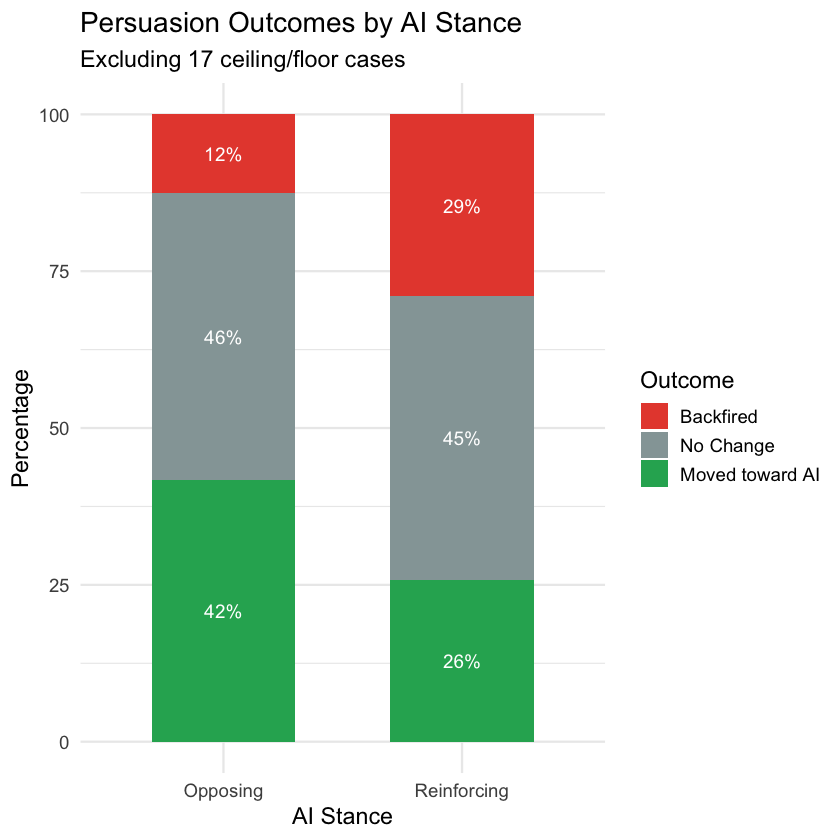

In [6]:
# Stacked bar plot: Outcome breakdown by stance
plot_data <- stance_outcomes_full %>%
  mutate(outcome = factor(outcome, levels = c("Backfired", "No Change", "Moved toward AI")))

p2 <- ggplot(plot_data, aes(x = stance_label, y = pct, fill = outcome)) +
  geom_col(width = 0.6) +
  geom_text(aes(label = ifelse(pct >= 5, sprintf("%.0f%%", pct), "")), 
            position = position_stack(vjust = 0.5), size = 4, color = "white") +
  scale_fill_manual(values = c(
    "Moved toward AI" = "#27AE60",
    "No Change" = "#95A5A6",
    "Backfired" = "#E74C3C"
  )) +
  labs(
    title = "Persuasion Outcomes by AI Stance",
    subtitle = sprintf("Excluding %d ceiling/floor cases", n_excluded),
    x = "AI Stance",
    y = "Percentage",
    fill = "Outcome"
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "right")

p2
ggsave("figures/02_outcomes_by_stance.png", p2, width = 8, height = 6, dpi = 300)
message("Saved: figures/02_outcomes_by_stance.png")

--- Statistical Test: Opposing vs Reinforcing ---

Excluded 17 ceiling/floor cases

Summary:



# A tibble: 2 × 6
  stance_label     n mean_movement median_movement sd_movement se_movement
  <chr>        <int>         <dbl>           <dbl>       <dbl>       <dbl>
1 Opposing        48         0.958               0        1.86       0.268
2 Reinforcing     31        -0.387               0        1.80       0.324



Opposing vs Reinforcing: mean=0.96 vs -0.39, W=974, p=0.0154 *

t-test: t(65.6) = 3.20, p = 0.0021 *


Binomial tests (H0: p=0.5, among those who changed):

  Opposing: 20/26 (76.9%), p=0.0047 *

  Reinforcing: 8/17 (47.1%), p=0.6855 



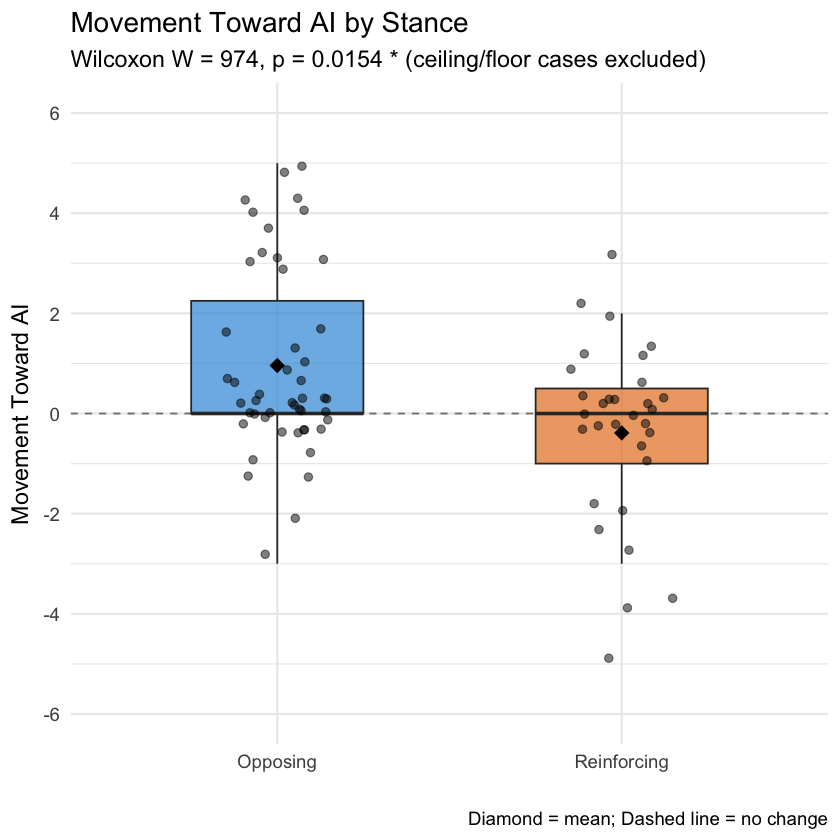

Saved: figures/05_stance_boxplot.png and figures/06_stance_means.png



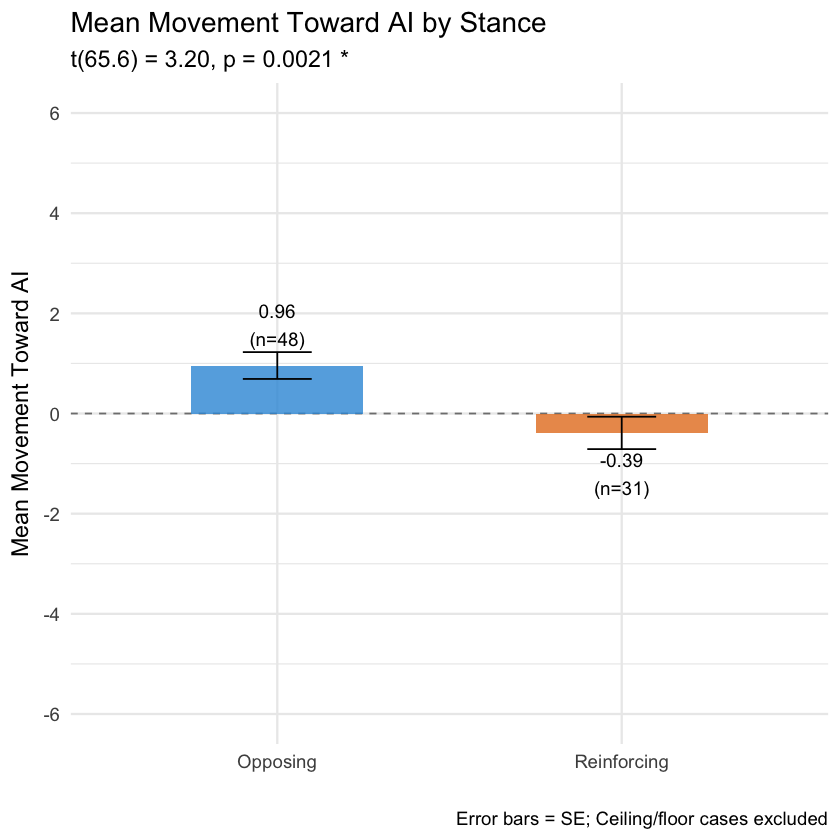

In [7]:
# Statistical Test: Opposing vs Reinforcing Stance
message("--- Statistical Test: Opposing vs Reinforcing ---")

# Exclude ceiling/floor cases for reinforcing stance
stance_data <- data_chat_analysis %>%
  filter(stance_label %in% c("Opposing", "Reinforcing")) %>%
  filter(
    stance_mode == "opposite" |
    (stance_mode == "same" & !rating_pre %in% c(1, 7))
  ) %>%
  mutate(
    movement_toward_ai = case_when(
      outcome == "Moved toward AI" ~ abs(rating_change),
      outcome == "Backfired" ~ -abs(rating_change),
      TRUE ~ 0
    )
  )

n_excluded_stance <- nrow(data_chat_analysis %>% 
  filter(stance_label %in% c("Opposing", "Reinforcing"))) - nrow(stance_data)
message(sprintf("Excluded %d ceiling/floor cases", n_excluded_stance))

# Summary stats
stance_stats <- stance_data %>%
  group_by(stance_label) %>%
  summarise(
    n = n(),
    mean_movement = mean(movement_toward_ai),
    median_movement = median(movement_toward_ai),
    sd_movement = sd(movement_toward_ai),
    se_movement = sd_movement / sqrt(n),
    .groups = "drop"
  )

message("Summary:")
print(stance_stats)

# Wilcoxon test
opposing_movement <- stance_data %>% filter(stance_label == "Opposing") %>% pull(movement_toward_ai)
reinforcing_movement <- stance_data %>% filter(stance_label == "Reinforcing") %>% pull(movement_toward_ai)

wilcox_res <- wilcox.test(opposing_movement, reinforcing_movement, exact = FALSE)
message(sprintf("\nOpposing vs Reinforcing: mean=%.2f vs %.2f, W=%.0f, p=%.4f %s",
              mean(opposing_movement), mean(reinforcing_movement),
              wilcox_res$statistic, wilcox_res$p.value,
              ifelse(wilcox_res$p.value < 0.05, "*", "")))

# Also run t-test for comparison
t_res <- t.test(opposing_movement, reinforcing_movement)
message(sprintf("t-test: t(%.1f) = %.2f, p = %.4f %s",
              t_res$parameter, t_res$statistic, t_res$p.value,
              ifelse(t_res$p.value < 0.05, "*", "")))

# Binomial tests per stance (among those who changed)
message("\nBinomial tests (H0: p=0.5, among those who changed):")
for (stance in c("Opposing", "Reinforcing")) {
  stance_changed <- stance_data %>%
    filter(stance_label == stance, outcome %in% c("Moved toward AI", "Backfired"))
  n_moved <- sum(stance_changed$outcome == "Moved toward AI")
  n_total <- nrow(stance_changed)
  if (n_total >= 2) {
    binom_res <- binom.test(n_moved, n_total, p = 0.5, alternative = "greater")
    message(sprintf("  %s: %d/%d (%.1f%%), p=%.4f %s",
                    stance, n_moved, n_total, n_moved/n_total*100, binom_res$p.value,
                    ifelse(binom_res$p.value < 0.05, "*", "")))
  }
}

# Boxplot with jittered points
p_stance_box <- ggplot(stance_data, aes(x = stance_label, y = movement_toward_ai, fill = stance_label)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  geom_boxplot(width = 0.5, alpha = 0.7, outlier.shape = NA) +
  geom_jitter(width = 0.15, alpha = 0.5, size = 2) +
  stat_summary(fun = mean, geom = "point", shape = 18, size = 4, color = "black") +
  scale_fill_manual(values = c("Opposing" = "#3498DB", "Reinforcing" = "#E67E22")) +
  scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
  labs(
    title = "Movement Toward AI by Stance",
    subtitle = sprintf("Wilcoxon W = %.0f, p = %.4f %s (ceiling/floor cases excluded)",
                       wilcox_res$statistic, wilcox_res$p.value,
                       ifelse(wilcox_res$p.value < 0.05, "*", "")),
    x = "", 
    y = "Movement Toward AI",
    caption = "Diamond = mean; Dashed line = no change"
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none")

# Mean bar chart with error bars
p_stance_mean <- ggplot(stance_stats, aes(x = stance_label, y = mean_movement, fill = stance_label)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  geom_col(width = 0.5, alpha = 0.8) +
  geom_errorbar(aes(ymin = mean_movement - se_movement, ymax = mean_movement + se_movement), width = 0.2) +
  geom_text(aes(label = sprintf("%.2f\n(n=%d)", mean_movement, n)),
            vjust = ifelse(stance_stats$mean_movement >= 0, -0.5, 1.5), size = 4) +
  scale_fill_manual(values = c("Opposing" = "#3498DB", "Reinforcing" = "#E67E22")) +
  scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
  labs(
    title = "Mean Movement Toward AI by Stance",
    subtitle = sprintf("t(%.1f) = %.2f, p = %.4f %s",
                       t_res$parameter, t_res$statistic, t_res$p.value,
                       ifelse(t_res$p.value < 0.05, "*", "")),
    x = "", 
    y = "Mean Movement Toward AI",
    caption = "Error bars = SE; Ceiling/floor cases excluded"
  ) +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none")

p_stance_box
p_stance_mean
ggsave("figures/05_stance_boxplot.png", p_stance_box, width = 8, height = 6, dpi = 300)
ggsave("figures/06_stance_means.png", p_stance_mean, width = 8, height = 6, dpi = 300)
message("Saved: figures/05_stance_boxplot.png and figures/06_stance_means.png")

In [8]:
# One-sample t-tests per stance (movement vs 0)
message("\nOne-sample t-tests (H0: mean=0):")
for (stance in c("Opposing", "Reinforcing")) {
stance_subset <- data_chat_analysis %>%
  filter(stance_label == stance) %>%
  mutate(
    movement_toward_ai = case_when(
      outcome == "Moved toward AI" ~ abs(rating_change),
      outcome == "Backfired" ~ -abs(rating_change),
      TRUE ~ 0
    )
  )

t_res <- t.test(stance_subset$movement_toward_ai, mu = 0)
message(sprintf("  %s: mean=%.2f, t=%.2f, df=%d, p=%.4f %s",
                stance,
                mean(stance_subset$movement_toward_ai),
                t_res$statistic,
                t_res$parameter,
                t_res$p.value,
                ifelse(t_res$p.value < 0.05, "*", "")))
}



One-sample t-tests (H0: mean=0):

  Opposing: mean=0.96, t=3.58, df=47, p=0.0008 *

  Reinforcing: mean=-0.27, t=-1.29, df=47, p=0.2034 




=== STANCE × CONDITION (Control vs Persuasion) ===

Summary:



# A tibble: 4 × 7
  stance_label condition_group     n mean_movement median_movement sd_movement
  <chr>        <fct>           <int>         <dbl>           <dbl>       <dbl>
1 Opposing     Control            12         0.5                 0        1.45
2 Opposing     Persuasion         36         1.11                0        1.97
3 Reinforcing  Control            12        -0.333               0        1.30
4 Reinforcing  Persuasion         36        -0.25                0        1.52
# ℹ 1 more variable: se_movement <dbl>



Overall: Kruskal-Wallis H=10.14, p=0.0174 *


Control vs Persuasion (by Stance):

  Opposing: mean=0.50 vs 1.11, W=168, p=0.2330 

  Reinforcing: mean=-0.33 vs -0.25, W=192, p=0.5284 


Opposing vs Reinforcing (by Condition):

  Control: mean=0.50 vs -0.33, W=90, p=0.2854 

  Persuasion: mean=1.11 vs -0.25, W=872, p=0.0053 *



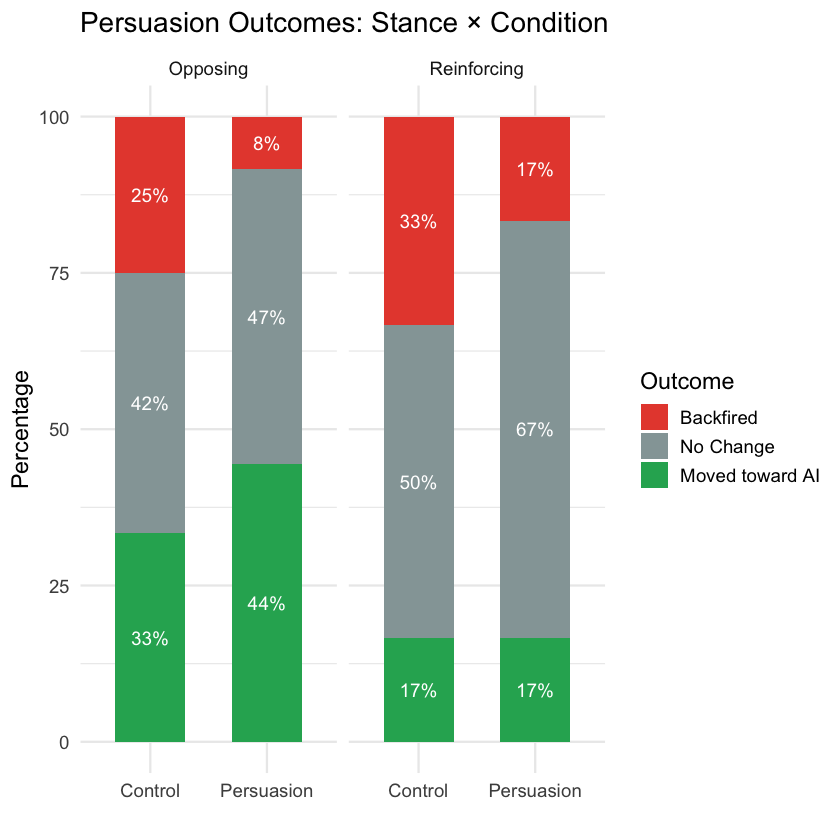

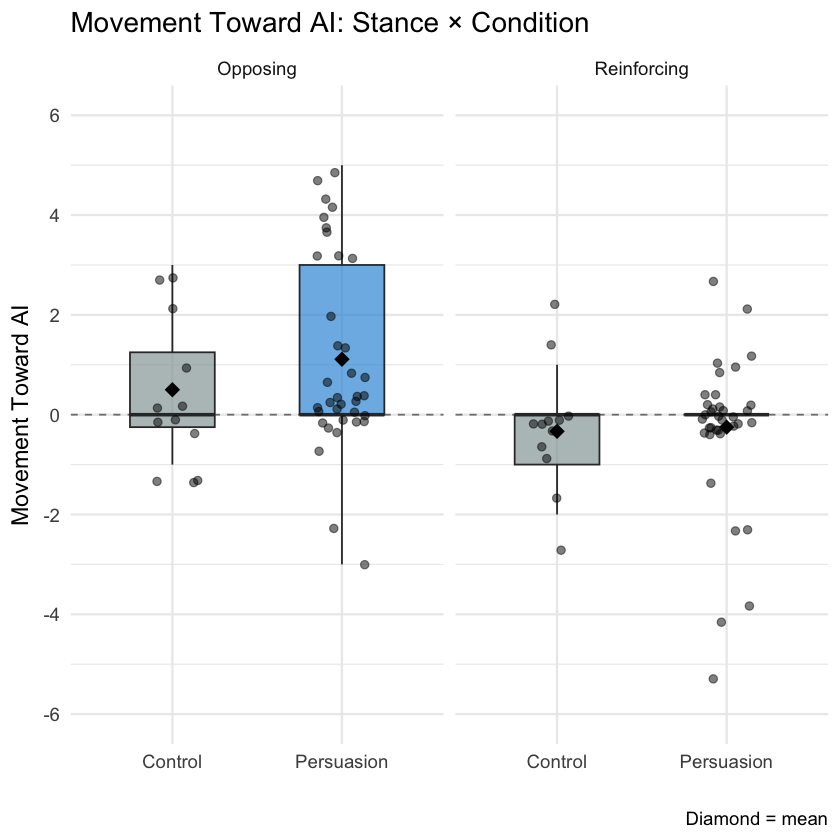

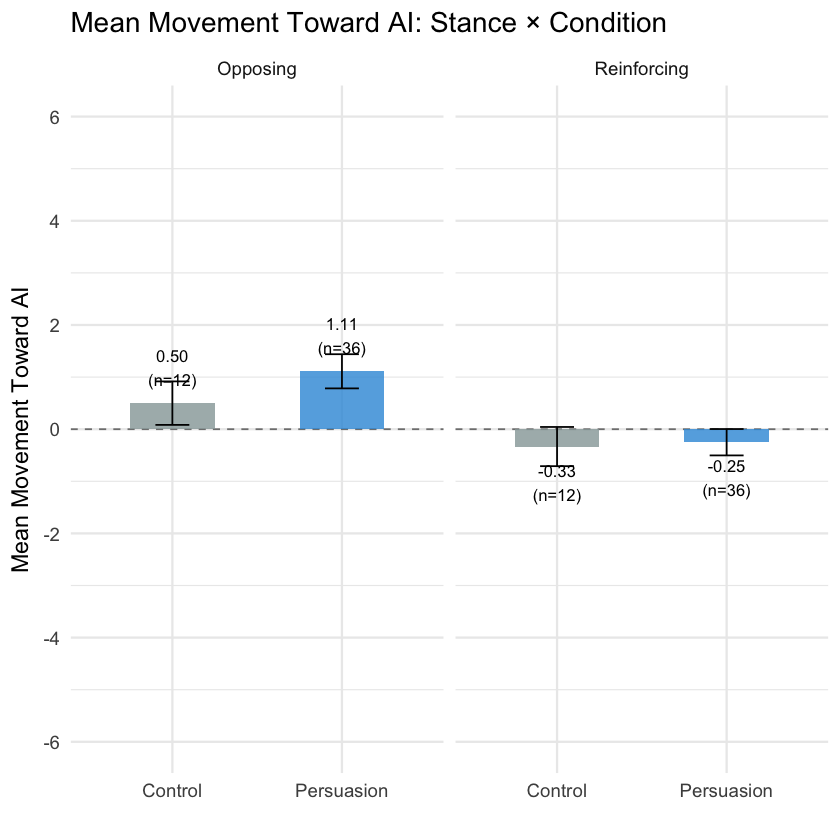

In [9]:

message("\n=== STANCE × CONDITION (Control vs Persuasion) ===")

stance_condition_data <- data_chat_analysis %>%
filter(stance_label %in% c("Opposing", "Reinforcing")) %>%
mutate(
  condition_group = case_when(
    condition %in% c("neutral", "Control") ~ "Control",
    condition %in% c("persuade", "persuade_demo", "persuade_info") ~ "Persuasion",
    TRUE ~ NA_character_
  ),
  condition_group = factor(condition_group, levels = c("Control", "Persuasion")),
  movement_toward_ai = case_when(
    outcome == "Moved toward AI" ~ abs(rating_change),
    outcome == "Backfired" ~ -abs(rating_change),
    TRUE ~ 0
  ),
  outcome = factor(outcome, levels = c("Backfired", "No Change", "Moved toward AI")),
  group = paste(stance_label, condition_group, sep = " × ")
) %>%
filter(!is.na(condition_group))

# Summary stats
stance_condition_stats <- stance_condition_data %>%
group_by(stance_label, condition_group) %>%
summarise(
  n = n(),
  mean_movement = mean(movement_toward_ai),
  median_movement = median(movement_toward_ai),
  sd_movement = sd(movement_toward_ai),
  se_movement = sd_movement / sqrt(n),
  .groups = "drop"
)

message("Summary:")
print(stance_condition_stats)

# Kruskal-Wallis (all 4 groups)
kruskal_res <- kruskal.test(movement_toward_ai ~ group, data = stance_condition_data)
message(sprintf("\nOverall: Kruskal-Wallis H=%.2f, p=%.4f %s",
              kruskal_res$statistic, kruskal_res$p.value,
              ifelse(kruskal_res$p.value < 0.05, "*", "")))

# Wilcoxon tests (Control vs Persuasion within each stance)
message("\nControl vs Persuasion (by Stance):")
for (stance in c("Opposing", "Reinforcing")) {
stance_data <- stance_condition_data %>% filter(stance_label == stance)
control_movement <- stance_data %>% filter(condition_group == "Control") %>% pull(movement_toward_ai)
persuasion_movement <- stance_data %>% filter(condition_group == "Persuasion") %>% pull(movement_toward_ai)

if (length(control_movement) >= 2 && length(persuasion_movement) >= 2) {
  wilcox_res <- wilcox.test(control_movement, persuasion_movement, exact = FALSE)
  message(sprintf("  %s: mean=%.2f vs %.2f, W=%.0f, p=%.4f %s",
                  stance, mean(control_movement), mean(persuasion_movement),
                  wilcox_res$statistic, wilcox_res$p.value,
                  ifelse(wilcox_res$p.value < 0.05, "*", "")))
}
}

# Wilcoxon tests (Opposing vs Reinforcing within each condition)
message("\nOpposing vs Reinforcing (by Condition):")
for (cond in c("Control", "Persuasion")) {
cond_data <- stance_condition_data %>% filter(condition_group == cond)
opposing_movement <- cond_data %>% filter(stance_label == "Opposing") %>% pull(movement_toward_ai)
reinforcing_movement <- cond_data %>% filter(stance_label == "Reinforcing") %>% pull(movement_toward_ai)

if (length(opposing_movement) >= 2 && length(reinforcing_movement) >= 2) {
  wilcox_res <- wilcox.test(opposing_movement, reinforcing_movement, exact = FALSE)
  message(sprintf("  %s: mean=%.2f vs %.2f, W=%.0f, p=%.4f %s",
                  cond, mean(opposing_movement), mean(reinforcing_movement),
                  wilcox_res$statistic, wilcox_res$p.value,
                  ifelse(wilcox_res$p.value < 0.05, "*", "")))
}
}

# 1. Stacked bar chart
outcome_pct_stance_cond <- stance_condition_data %>%
count(stance_label, condition_group, outcome) %>%
group_by(stance_label, condition_group) %>%
mutate(pct = n / sum(n) * 100) %>%
ungroup()

ggplot(outcome_pct_stance_cond, aes(x = condition_group, y = pct, fill = outcome)) +
geom_col(position = "stack", width = 0.6) +
geom_text(aes(label = ifelse(pct >= 5, sprintf("%.0f%%", pct), "")),
          position = position_stack(vjust = 0.5), size = 4, color = "white") +
facet_wrap(~ stance_label) +
scale_fill_manual(values = c("Backfired" = "#E74C3C", "No Change" = "#95A5A6", "Moved toward AI" = "#27AE60")) +
labs(title = "Persuasion Outcomes: Stance × Condition", x = "", y = "Percentage", fill = "Outcome") +
theme_minimal(base_size = 14) +
theme(legend.position = "right")

# 2. Boxplot
ggplot(stance_condition_data, aes(x = condition_group, y = movement_toward_ai, fill = condition_group)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_boxplot(width = 0.5, alpha = 0.7, outlier.shape = NA) +
geom_jitter(width = 0.15, alpha = 0.5, size = 2) +
stat_summary(fun = mean, geom = "point", shape = 18, size = 4, color = "black") +
facet_wrap(~ stance_label) +
scale_fill_manual(values = c("Control" = "#95A5A6", "Persuasion" = "#3498DB")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Movement Toward AI: Stance × Condition", x = "", y = "Movement Toward AI",
     caption = "Diamond = mean") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")

# 3. Mean bar chart
ggplot(stance_condition_stats, aes(x = condition_group, y = mean_movement, fill = condition_group)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_col(width = 0.5, alpha = 0.8) +
geom_errorbar(aes(ymin = mean_movement - se_movement, ymax = mean_movement + se_movement), width = 0.2) +
geom_text(aes(label = sprintf("%.2f\n(n=%d)", mean_movement, n)),
          vjust = ifelse(stance_condition_stats$mean_movement >= 0, -0.5, 1.5), size = 3.5) +
facet_wrap(~ stance_label) +
scale_fill_manual(values = c("Control" = "#95A5A6", "Persuasion" = "#3498DB")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Mean Movement Toward AI: Stance × Condition", x = "", y = "Mean Movement Toward AI") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")


## Condition Comparison (Control vs Persuasion)


=== CONDITION COMPARISON: Control vs Persuasion ===

Summary:



# A tibble: 2 × 6
  condition_group     n mean_movement median_movement sd_movement se_movement
  <fct>           <int>         <dbl>           <dbl>       <dbl>       <dbl>
1 Control            24        0.0833               0        1.41       0.288
2 Persuasion         72        0.431                0        1.88       0.221



Control vs Persuasion: mean=0.08 vs 0.43, W=728, p=0.2123 


Binomial tests (H0: p=0.5, among those who changed):

  Control: 6/13 (46.2%), p=0.7095 

  Persuasion: 22/31 (71.0%), p=0.0147 *



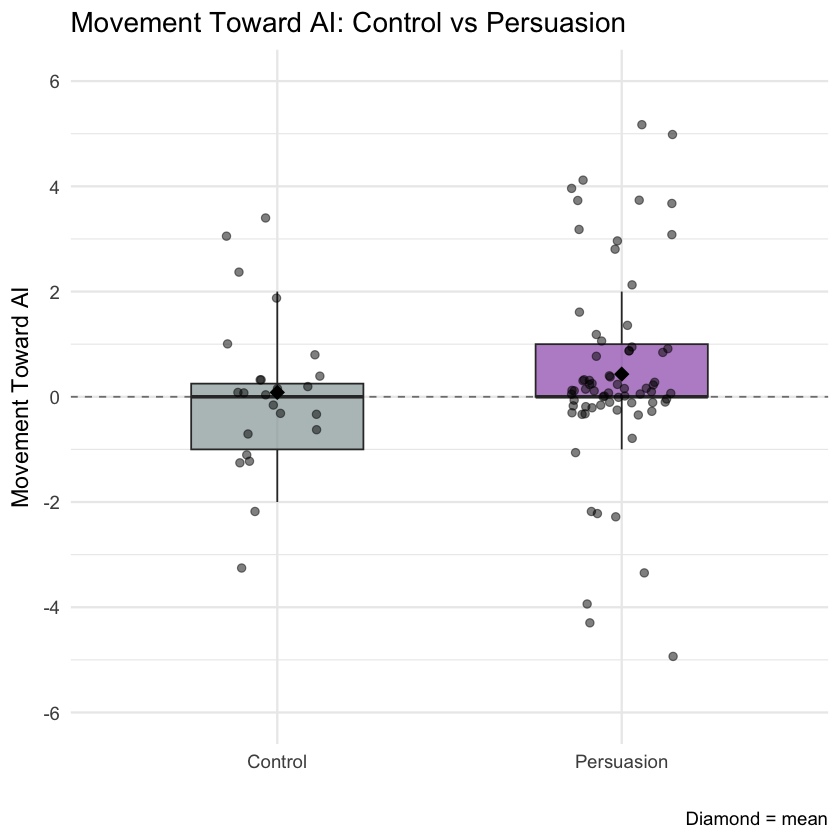

Saved: figures/03_control_vs_persuasion.png



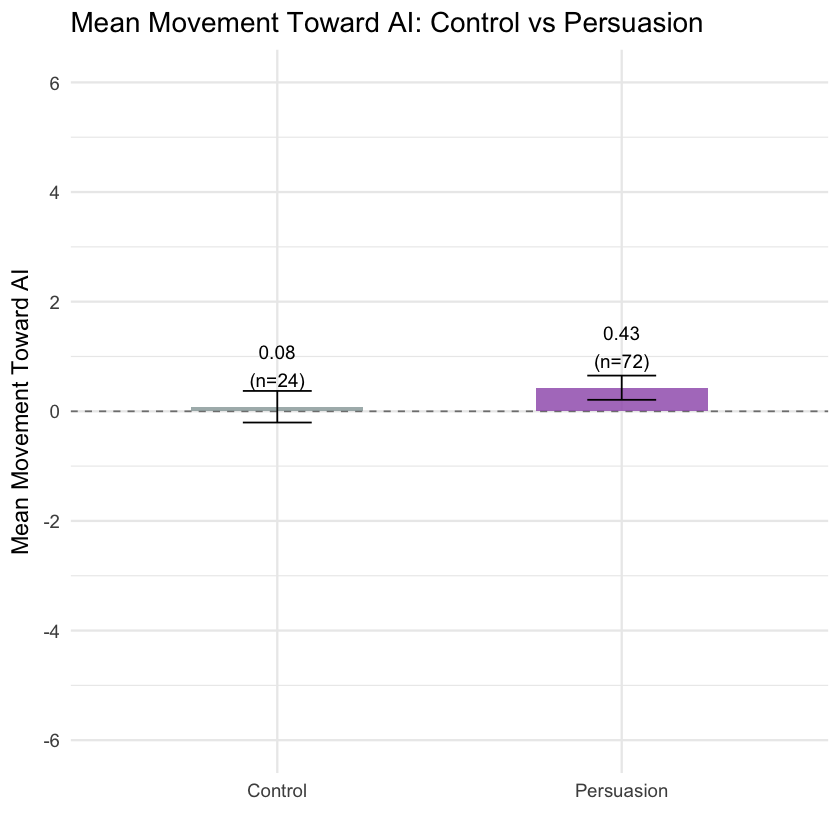

Saved: figures/07_control_vs_persuasion_means.png



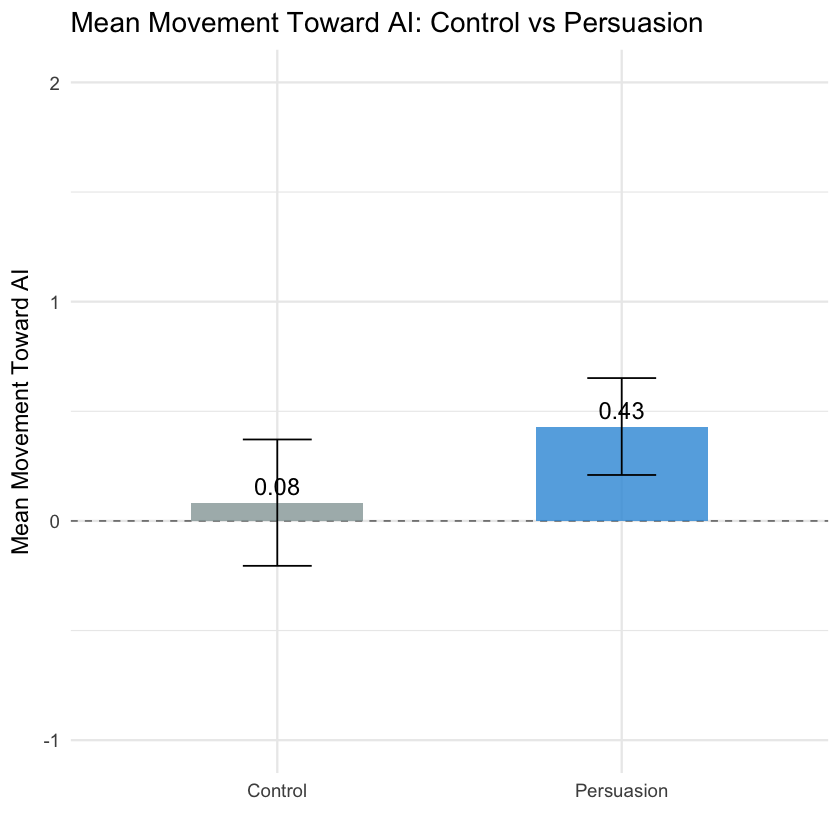

In [10]:
message("\n=== CONDITION COMPARISON: Control vs Persuasion ===")

condition_data <- data_chat_analysis %>%
mutate(
  condition_group = case_when(
    condition %in% c("neutral", "Control") ~ "Control",
    condition %in% c("persuade", "persuade_demo", "persuade_info") ~ "Persuasion",
    TRUE ~ NA_character_
  ),
  condition_group = factor(condition_group, levels = c("Control", "Persuasion")),
  movement_toward_ai = case_when(
    outcome == "Moved toward AI" ~ abs(rating_change),
    outcome == "Backfired" ~ -abs(rating_change),
    TRUE ~ 0
  ),
  outcome = factor(outcome, levels = c("Backfired", "No Change", "Moved toward AI"))
) %>%
filter(!is.na(condition_group))

# Summary stats
condition_stats <- condition_data %>%
group_by(condition_group) %>%
summarise(
  n = n(),
  mean_movement = mean(movement_toward_ai),
  median_movement = median(movement_toward_ai),
  sd_movement = sd(movement_toward_ai),
  se_movement = sd_movement / sqrt(n),
  .groups = "drop"
)

message("Summary:")
print(condition_stats)

# Wilcoxon test
control_movement <- condition_data %>% filter(condition_group == "Control") %>% pull(movement_toward_ai)
persuasion_movement <- condition_data %>% filter(condition_group == "Persuasion") %>% pull(movement_toward_ai)

wilcox_res <- wilcox.test(control_movement, persuasion_movement, exact = FALSE)
message(sprintf("\nControl vs Persuasion: mean=%.2f vs %.2f, W=%.0f, p=%.4f %s",
              mean(control_movement), mean(persuasion_movement),
              wilcox_res$statistic, wilcox_res$p.value,
              ifelse(wilcox_res$p.value < 0.05, "*", "")))

# Binomial tests (among those who changed)
message("\nBinomial tests (H0: p=0.5, among those who changed):")
for (grp in c("Control", "Persuasion")) {
grp_changed <- condition_data %>%
  filter(condition_group == grp, outcome %in% c("Moved toward AI", "Backfired"))
n_moved <- sum(grp_changed$outcome == "Moved toward AI")
n_total <- nrow(grp_changed)
if (n_total >= 2) {
  binom_res <- binom.test(n_moved, n_total, p = 0.5, alternative = "greater")
  message(sprintf("  %s: %d/%d (%.1f%%), p=%.4f %s",
                  grp, n_moved, n_total, n_moved/n_total*100, binom_res$p.value,
                  ifelse(binom_res$p.value < 0.05, "*", "")))
}
}

# 1. Stacked bar chart
outcome_pct_cond <- condition_data %>%
count(condition_group, outcome) %>%
group_by(condition_group) %>%
mutate(pct = n / sum(n) * 100) %>%
ungroup()

p3 <- ggplot(outcome_pct_cond, aes(x = condition_group, y = pct, fill = outcome)) +
geom_col(position = "stack", width = 0.6) +
geom_text(aes(label = ifelse(pct >= 5, sprintf("%.0f%%", pct), "")),
          position = position_stack(vjust = 0.5), size = 4, color = "white") +
scale_fill_manual(values = c("Backfired" = "#E74C3C", "No Change" = "#95A5A6", "Moved toward AI" = "#27AE60")) +
labs(title = "Persuasion Outcomes: Control vs Persuasion", x = "", y = "Percentage", fill = "Outcome") +
theme_minimal(base_size = 14) +
theme(legend.position = "right")

# 2. Boxplot
ggplot(condition_data, aes(x = condition_group, y = movement_toward_ai, fill = condition_group)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_boxplot(width = 0.5, alpha = 0.7, outlier.shape = NA) +
geom_jitter(width = 0.15, alpha = 0.5, size = 2) +
stat_summary(fun = mean, geom = "point", shape = 18, size = 4, color = "black") +
scale_fill_manual(values = c("Control" = "#95A5A6", "Persuasion" = "#9B59B6")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Movement Toward AI: Control vs Persuasion", x = "", y = "Movement Toward AI",
     caption = "Diamond = mean") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")

# 3. Mean bar chart
ggplot(condition_stats, aes(x = condition_group, y = mean_movement, fill = condition_group)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_col(width = 0.5, alpha = 0.8) +
geom_errorbar(aes(ymin = mean_movement - se_movement, ymax = mean_movement + se_movement), width = 0.2) +
geom_text(aes(label = sprintf("%.2f\n(n=%d)", mean_movement, n)),
          vjust = ifelse(condition_stats$mean_movement >= 0, -0.5, 1.5), size = 4) +
scale_fill_manual(values = c("Control" = "#95A5A6", "Persuasion" = "#9B59B6")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Mean Movement Toward AI: Control vs Persuasion", x = "", y = "Mean Movement Toward AI") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")

ggsave("figures/03_control_vs_persuasion.png", p3, width = 8, height = 6, dpi = 300)
message("Saved: figures/03_control_vs_persuasion.png")

# Mean movement bar chart
p_cond_mean <- ggplot(condition_stats, aes(x = condition_group, y = mean_movement, fill = condition_group)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  geom_col(width = 0.5, alpha = 0.8) +
  geom_errorbar(aes(ymin = mean_movement - se_movement, ymax = mean_movement + se_movement), width = 0.2) +
  geom_text(aes(label = sprintf("%.2f", mean_movement)),
            vjust = ifelse(condition_stats$mean_movement >= 0, -0.5, 1.5), size = 5) +
  scale_fill_manual(values = c("Control" = "#95A5A6", "Persuasion" = "#3498DB")) +
  scale_y_continuous(limits = c(-1, 2)) +
  labs(title = "Mean Movement Toward AI: Control vs Persuasion", 
       x = "", y = "Mean Movement Toward AI") +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none")

p_cond_mean
ggsave("figures/07_control_vs_persuasion_means.png", p_cond_mean, width = 8, height = 6, dpi = 300)
message("Saved: figures/07_control_vs_persuasion_means.png")

In [11]:
# One-sample t-tests per condition (H0: mean=0)
message("\nOne-sample t-tests by condition (H0: mean=0):")
for (cond in c("Control", "Persuasion")) {
cond_subset <- condition_data %>%
  filter(condition_group == cond)

t_res <- t.test(cond_subset$movement_toward_ai, mu = 0)
message(sprintf("  %s: mean=%.2f, t=%.2f, df=%d, p=%.4f %s",
                cond,
                mean(cond_subset$movement_toward_ai),
                t_res$statistic,
                t_res$parameter,
                t_res$p.value,
                ifelse(t_res$p.value < 0.05, "*", "")))
}





One-sample t-tests by condition (H0: mean=0):

  Control: mean=0.08, t=0.29, df=23, p=0.7750 

  Persuasion: mean=0.43, t=1.95, df=71, p=0.0553 




=== ALL CONDITIONS COMPARISON ===

Summary:



# A tibble: 4 × 6
  condition_label     n mean_movement median_movement sd_movement se_movement
  <fct>           <int>         <dbl>           <dbl>       <dbl>       <dbl>
1 Control            24        0.0833               0        1.41       0.288
2 Persuade           16        0.438                0        1.15       0.288
3 Demo               24        0.458                0        1.74       0.356
4 Info               32        0.406                0        2.27       0.401



Overall: Kruskal-Wallis H=1.81, p=0.6134 


Pairwise comparisons:

  Control vs Persuade: mean=0.08 vs 0.44, W=159, p=0.3244 

  Control vs Demo: mean=0.08 vs 0.46, W=230, p=0.1960 

  Control vs Info: mean=0.08 vs 0.41, W=340, p=0.4439 

  Persuade vs Demo: mean=0.44 vs 0.46, W=179, p=0.6910 

  Persuade vs Info: mean=0.44 vs 0.41, W=262, p=0.8943 

  Demo vs Info: mean=0.46 vs 0.41, W=406, p=0.7050 



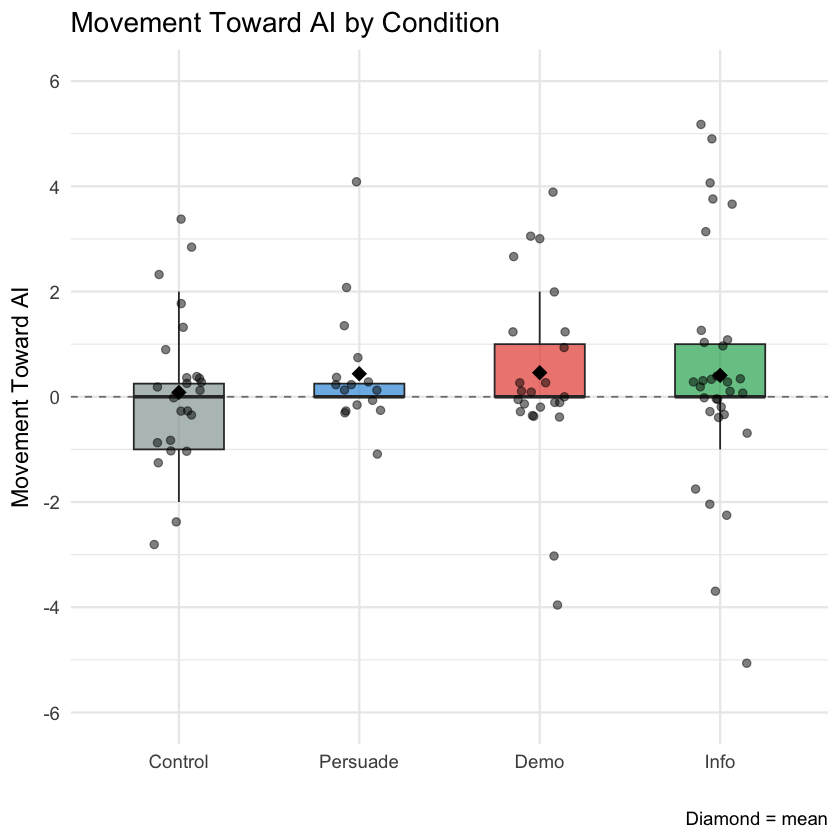

Saved: figures/04_outcomes_by_condition.png



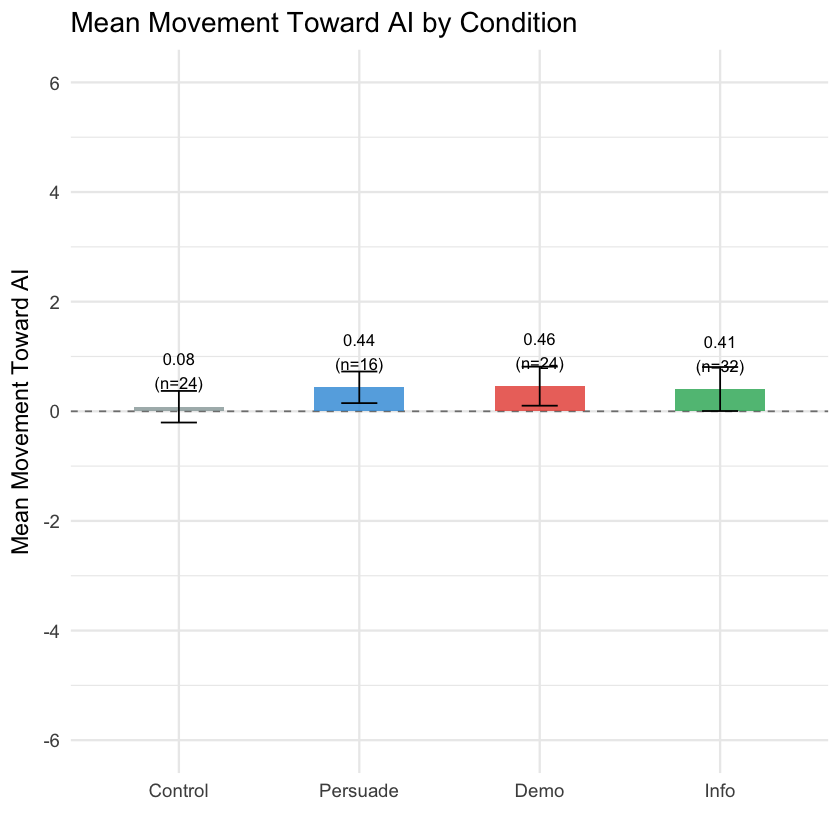

Saved: figures/08_all_conditions_means.png



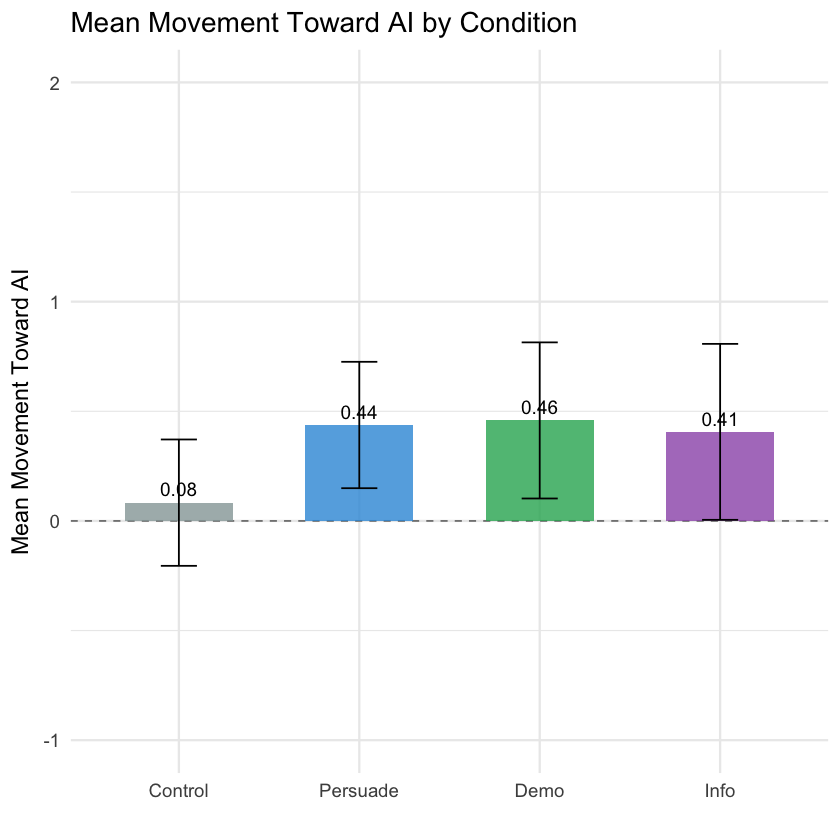

In [12]:
message("\n=== ALL CONDITIONS COMPARISON ===")

all_conditions_data <- data_chat_analysis %>%
mutate(
  condition_label = factor(case_when(
    condition %in% c("neutral", "Control") ~ "Control",
    condition == "persuade" ~ "Persuade",
    condition == "persuade_demo" ~ "Demo",
    condition == "persuade_info" ~ "Info",
    TRUE ~ NA_character_
  ), levels = c("Control", "Persuade", "Demo", "Info")),
  movement_toward_ai = case_when(
    outcome == "Moved toward AI" ~ abs(rating_change),
    outcome == "Backfired" ~ -abs(rating_change),
    TRUE ~ 0
  ),
  outcome = factor(outcome, levels = c("Backfired", "No Change", "Moved toward AI"))
) %>%
filter(!is.na(condition_label))

# Summary stats
all_conditions_stats <- all_conditions_data %>%
group_by(condition_label) %>%
summarise(
  n = n(),
  mean_movement = mean(movement_toward_ai),
  median_movement = median(movement_toward_ai),
  sd_movement = sd(movement_toward_ai),
  se_movement = sd_movement / sqrt(n),
  .groups = "drop"
)

message("Summary:")
print(all_conditions_stats)

# Kruskal-Wallis (overall)
kruskal_res <- kruskal.test(movement_toward_ai ~ condition_label, data = all_conditions_data)
message(sprintf("\nOverall: Kruskal-Wallis H=%.2f, p=%.4f %s",
              kruskal_res$statistic, kruskal_res$p.value,
              ifelse(kruskal_res$p.value < 0.05, "*", "")))

# Pairwise Wilcoxon
message("\nPairwise comparisons:")
conditions <- c("Control", "Persuade", "Demo", "Info")
for (i in 1:(length(conditions)-1)) {
for (j in (i+1):length(conditions)) {
  c1 <- conditions[i]
  c2 <- conditions[j]

  data1 <- all_conditions_data %>% filter(condition_label == c1) %>% pull(movement_toward_ai)
  data2 <- all_conditions_data %>% filter(condition_label == c2) %>% pull(movement_toward_ai)

  if (length(data1) >= 2 && length(data2) >= 2) {
    wilcox_res <- wilcox.test(data1, data2, exact = FALSE)
    message(sprintf("  %s vs %s: mean=%.2f vs %.2f, W=%.0f, p=%.4f %s",
                    c1, c2, mean(data1), mean(data2),
                    wilcox_res$statistic, wilcox_res$p.value,
                    ifelse(wilcox_res$p.value < 0.05, "*", "")))
  }
}
}

# 1. Stacked bar chart
outcome_pct_all <- all_conditions_data %>%
count(condition_label, outcome) %>%
group_by(condition_label) %>%
mutate(pct = n / sum(n) * 100) %>%
ungroup()

p4 <- ggplot(outcome_pct_all, aes(x = condition_label, y = pct, fill = outcome)) +
geom_col(position = "stack", width = 0.6) +
geom_text(aes(label = ifelse(pct >= 5, sprintf("%.0f%%", pct), "")),
          position = position_stack(vjust = 0.5), size = 4, color = "white") +
scale_fill_manual(values = c("Backfired" = "#E74C3C", "No Change" = "#95A5A6", "Moved toward AI" = "#27AE60")) +
labs(title = "Persuasion Outcomes by Condition", x = "", y = "Percentage", fill = "Outcome") +
theme_minimal(base_size = 14) +
theme(legend.position = "right")

# 2. Boxplot
ggplot(all_conditions_data, aes(x = condition_label, y = movement_toward_ai, fill = condition_label)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_boxplot(width = 0.5, alpha = 0.7, outlier.shape = NA) +
geom_jitter(width = 0.15, alpha = 0.5, size = 2) +
stat_summary(fun = mean, geom = "point", shape = 18, size = 4, color = "black") +
scale_fill_manual(values = c("Control" = "#95A5A6", "Persuade" = "#3498DB", "Demo" = "#E74C3C", "Info" = "#27AE60")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Movement Toward AI by Condition", x = "", y = "Movement Toward AI",
     caption = "Diamond = mean") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")

# 3. Mean bar chart
ggplot(all_conditions_stats, aes(x = condition_label, y = mean_movement, fill = condition_label)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_col(width = 0.5, alpha = 0.8) +
geom_errorbar(aes(ymin = mean_movement - se_movement, ymax = mean_movement + se_movement), width = 0.2) +
geom_text(aes(label = sprintf("%.2f\n(n=%d)", mean_movement, n)),
          vjust = ifelse(all_conditions_stats$mean_movement >= 0, -0.5, 1.5), size = 3.5) +
scale_fill_manual(values = c("Control" = "#95A5A6", "Persuade" = "#3498DB", "Demo" = "#E74C3C", "Info" = "#27AE60")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Mean Movement Toward AI by Condition", x = "", y = "Mean Movement Toward AI") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")

ggsave("figures/04_outcomes_by_condition.png", p4, width = 10, height = 6, dpi = 300)
message("Saved: figures/04_outcomes_by_condition.png")

# Mean movement bar chart - all conditions
p_all_cond_mean <- ggplot(all_conditions_stats, aes(x = condition_label, y = mean_movement, fill = condition_label)) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  geom_col(width = 0.6, alpha = 0.8) +
  geom_errorbar(aes(ymin = mean_movement - se_movement, ymax = mean_movement + se_movement), width = 0.2) +
  geom_text(aes(label = sprintf("%.2f", mean_movement)),
            vjust = ifelse(all_conditions_stats$mean_movement >= 0, -0.5, 1.5), size = 4) +
  scale_fill_manual(values = c("Control" = "#95A5A6", "Persuade" = "#3498DB", 
                               "Demo" = "#27AE60", "Info" = "#9B59B6")) +
  scale_y_continuous(limits = c(-1, 2)) +
  labs(title = "Mean Movement Toward AI by Condition", 
       x = "", y = "Mean Movement Toward AI") +
  theme_minimal(base_size = 14) +
  theme(legend.position = "none")

p_all_cond_mean
ggsave("figures/08_all_conditions_means.png", p_all_cond_mean, width = 10, height = 6, dpi = 300)
message("Saved: figures/08_all_conditions_means.png")

In [13]:
# One-sample t-tests per condition (H0: mean=0)
message("\nOne-sample t-tests by condition (H0: mean=0):")
for (cond in unique(all_conditions_data$condition_label)) {
cond_subset <- all_conditions_data %>%
  filter(condition_label == cond)

t_res <- t.test(cond_subset$movement_toward_ai, mu = 0)
message(sprintf("  %s: mean=%.2f, t=%.2f, df=%d, p=%.4f %s",
                cond,
                mean(cond_subset$movement_toward_ai),
                t_res$statistic,
                t_res$parameter,
                t_res$p.value,
                ifelse(t_res$p.value < 0.05, "*", "")))
}


One-sample t-tests by condition (H0: mean=0):

  Persuade: mean=0.44, t=1.52, df=15, p=0.1498 

  Control: mean=0.08, t=0.29, df=23, p=0.7750 

  Info: mean=0.41, t=1.01, df=31, p=0.3192 

  Demo: mean=0.46, t=1.29, df=23, p=0.2107 




=== CONDITION COMPARISON: Control vs Non-personalized vs Personalized ===

Summary by Condition Type:



# A tibble: 3 × 5
  condition_type       n mean_movement sd_movement se_movement
  <fct>            <int>         <dbl>       <dbl>       <dbl>
1 Control             24        0.0833        1.41       0.288
2 Non-personalized    16        0.438         1.15       0.288
3 Personalized        56        0.429         2.04       0.273



Kruskal-Wallis (all 3 groups): H=1.57, p=0.4563 


--- Pairwise Comparisons ---


Control vs Non-personalized

  Control: mean=0.08, median=0.0 (n=24)

  Non-personalized: mean=0.44, median=0.0 (n=16)

  Wilcoxon: W=159, p=0.3244 


Control vs Personalized

  Control: mean=0.08, median=0.0 (n=24)

  Personalized: mean=0.43, median=0.0 (n=56)

  Wilcoxon: W=570, p=0.2490 


Non-personalized vs Personalized

  Non-personalized: mean=0.44, median=0.0 (n=16)

  Personalized: mean=0.43, median=0.0 (n=56)

  Wilcoxon: W=441, p=0.9222 



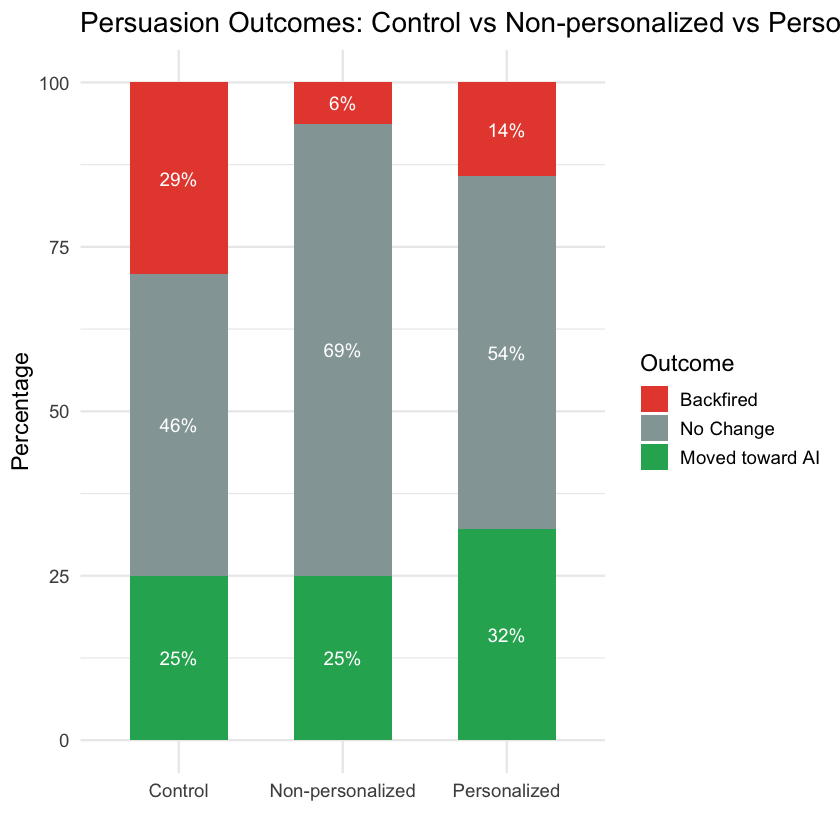

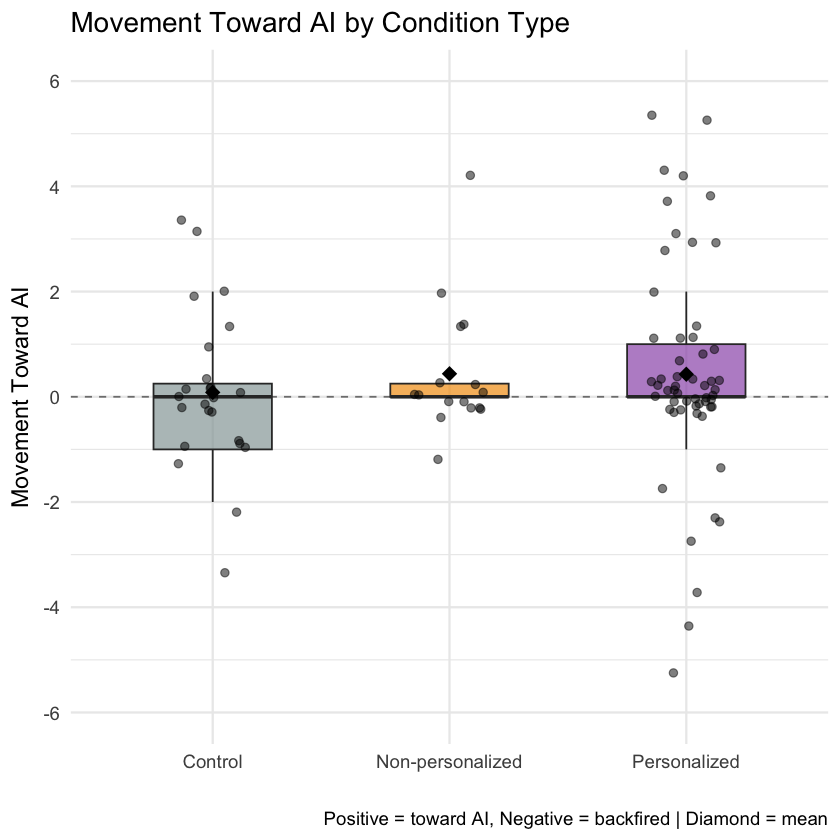

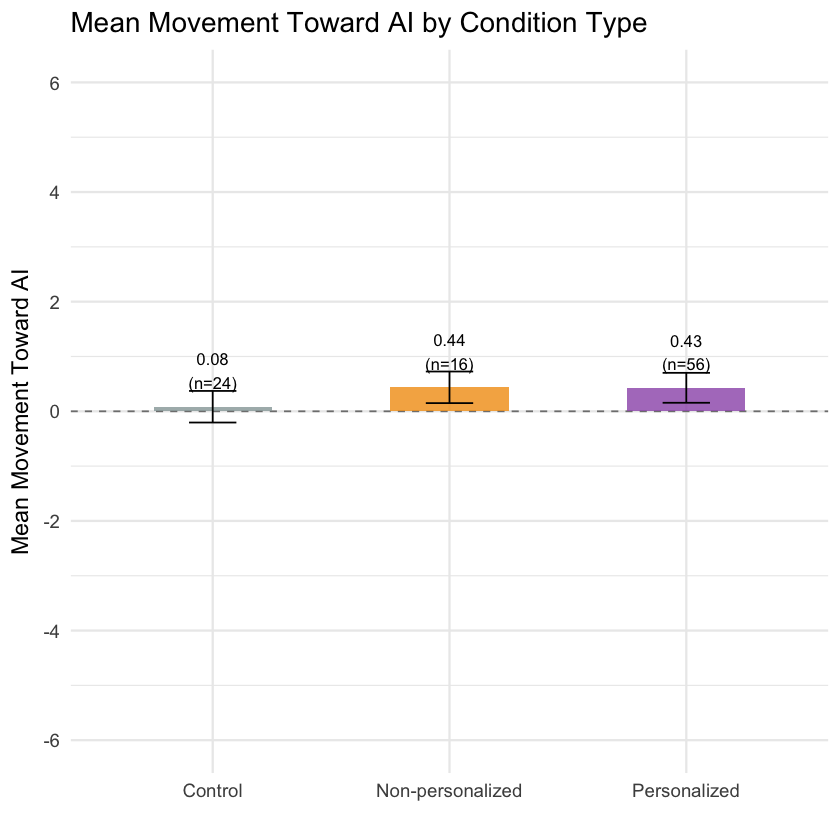

In [14]:

# =============================================================================
# CONDITION COMPARISON: Control vs Non-personalized vs Personalized
# =============================================================================

message("\n=== CONDITION COMPARISON: Control vs Non-personalized vs Personalized ===")

condition_3way_data <- data_chat_analysis %>%
mutate(
  condition_type = case_when(
    condition %in% c("neutral", "Control") ~ "Control",
    condition == "persuade" ~ "Non-personalized",
    condition %in% c("persuade_demo", "persuade_info") ~ "Personalized",
    TRUE ~ NA_character_
  ),
  condition_type = factor(condition_type, levels = c("Control", "Non-personalized", "Personalized")),
  movement_toward_ai = case_when(
    outcome == "Moved toward AI" ~ abs(rating_change),
    outcome == "Backfired" ~ -abs(rating_change),
    TRUE ~ 0
  ),
  outcome = factor(outcome, levels = c("Backfired", "No Change", "Moved toward AI"))
) %>%
filter(!is.na(condition_type))

# Summary stats
condition_3way_stats <- condition_3way_data %>%
group_by(condition_type) %>%
summarise(
  n = n(),
  mean_movement = mean(movement_toward_ai),
  sd_movement = sd(movement_toward_ai),
  se_movement = sd_movement / sqrt(n),
  .groups = "drop"
)

message("Summary by Condition Type:")
print(condition_3way_stats)

# Kruskal-Wallis (all 3 groups)
kruskal_res <- kruskal.test(movement_toward_ai ~ condition_type, data = condition_3way_data)
message(sprintf("\nKruskal-Wallis (all 3 groups): H=%.2f, p=%.4f %s",
              kruskal_res$statistic, kruskal_res$p.value,
              ifelse(kruskal_res$p.value < 0.05, "*", "")))

# Pairwise Wilcoxon comparisons
message("\n--- Pairwise Comparisons ---")
conditions <- c("Control", "Non-personalized", "Personalized")

for (i in 1:(length(conditions)-1)) {
for (j in (i+1):length(conditions)) {
  c1 <- conditions[i]
  c2 <- conditions[j]

  data1 <- condition_3way_data %>% filter(condition_type == c1) %>% pull(movement_toward_ai)
  data2 <- condition_3way_data %>% filter(condition_type == c2) %>% pull(movement_toward_ai)

  message(sprintf("\n%s vs %s", c1, c2))
  message(sprintf("  %s: mean=%.2f, median=%.1f (n=%d)", c1, mean(data1), median(data1), length(data1)))
  message(sprintf("  %s: mean=%.2f, median=%.1f (n=%d)", c2, mean(data2), median(data2), length(data2)))

  if (length(data1) >= 2 && length(data2) >= 2) {
    wilcox_res <- wilcox.test(data1, data2, exact = FALSE)
    message(sprintf("  Wilcoxon: W=%.0f, p=%.4f %s",
                    wilcox_res$statistic, wilcox_res$p.value,
                    ifelse(wilcox_res$p.value < 0.05, "*", "")))
  }
}
}

# 1. Stacked bar chart - outcome distribution
outcome_pct_3way <- condition_3way_data %>%
count(condition_type, outcome) %>%
group_by(condition_type) %>%
mutate(pct = n / sum(n) * 100) %>%
ungroup()

ggplot(outcome_pct_3way, aes(x = condition_type, y = pct, fill = outcome)) +
geom_col(position = "stack", width = 0.6) +
geom_text(aes(label = ifelse(pct >= 5, sprintf("%.0f%%", pct), "")),
          position = position_stack(vjust = 0.5), size = 4, color = "white") +
scale_fill_manual(values = c("Backfired" = "#E74C3C", "No Change" = "#95A5A6", "Moved toward AI" = "#27AE60")) +
labs(title = "Persuasion Outcomes: Control vs Non-personalized vs Personalized",
     x = "", y = "Percentage", fill = "Outcome") +
theme_minimal(base_size = 14) +
theme(legend.position = "right")

# 2. Boxplot - movement toward AI distribution
ggplot(condition_3way_data, aes(x = condition_type, y = movement_toward_ai, fill = condition_type)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_boxplot(width = 0.5, alpha = 0.7, outlier.shape = NA) +
geom_jitter(width = 0.15, alpha = 0.5, size = 2) +
stat_summary(fun = mean, geom = "point", shape = 18, size = 4, color = "black") +
scale_fill_manual(values = c("Control" = "#95A5A6", "Non-personalized" = "#F39C12", "Personalized" = "#9B59B6")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Movement Toward AI by Condition Type",
     x = "", y = "Movement Toward AI",
     caption = "Positive = toward AI, Negative = backfired | Diamond = mean") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")

# 3. Bar chart - mean movement toward AI
ggplot(condition_3way_stats, aes(x = condition_type, y = mean_movement, fill = condition_type)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_col(width = 0.5, alpha = 0.8) +
geom_errorbar(aes(ymin = mean_movement - se_movement, ymax = mean_movement + se_movement), width = 0.2) +
geom_text(aes(label = sprintf("%.2f\n(n=%d)", mean_movement, n)),
          vjust = ifelse(condition_3way_stats$mean_movement >= 0, -0.5, 1.5), size = 3.5) +
scale_fill_manual(values = c("Control" = "#95A5A6", "Non-personalized" = "#F39C12", "Personalized" = "#9B59B6")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Mean Movement Toward AI by Condition Type",
     x = "", y = "Mean Movement Toward AI") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")


In [15]:
# One-sample t-tests - personalized vs non-personalized (H0: mean=0)
message("\nOne-sample t-tests - personalized vs non-personalized (H0: mean=0):")
for (cond in c("Control", "Personalized", "Non-personalized")) {
cond_subset <- condition_3way_data %>%
  filter(condition_type == cond)

t_res <- t.test(cond_subset$movement_toward_ai, mu = 0)
message(sprintf("  %s: mean=%.2f, t=%.2f, df=%d, p=%.4f %s",
                cond,
                mean(cond_subset$movement_toward_ai),
                t_res$statistic,
                t_res$parameter,
                t_res$p.value,
                ifelse(t_res$p.value < 0.05, "*", "")))
}


One-sample t-tests - personalized vs non-personalized (H0: mean=0):

  Control: mean=0.08, t=0.29, df=23, p=0.7750 

  Personalized: mean=0.43, t=1.57, df=55, p=0.1223 

  Non-personalized: mean=0.44, t=1.52, df=15, p=0.1498 



## LLM Comparison (Claude vs Qwen)


=== LLM COMPARISON: Claude vs Qwen ===

Summary:



# A tibble: 2 × 6
  llm_label     n mean_movement median_movement sd_movement se_movement
  <fct>     <int>         <dbl>           <dbl>       <dbl>       <dbl>
1 Claude       44          0.75               0        1.75       0.264
2 Qwen         52          0                  0        1.73       0.239



Claude vs Qwen: mean=0.75 vs 0.00, W=1406, p=0.0361 *


One-sample tests (H0: mean = 0):

  Claude: mean=0.75, V=208, p=0.0083 *

  Qwen: mean=0.00, V=126, p=0.9869 


Binomial tests (H0: p=0.5, among those who changed):

  Claude: 17/22 (77.3%), p=0.0085 *

  Qwen: 11/22 (50.0%), p=0.5841 



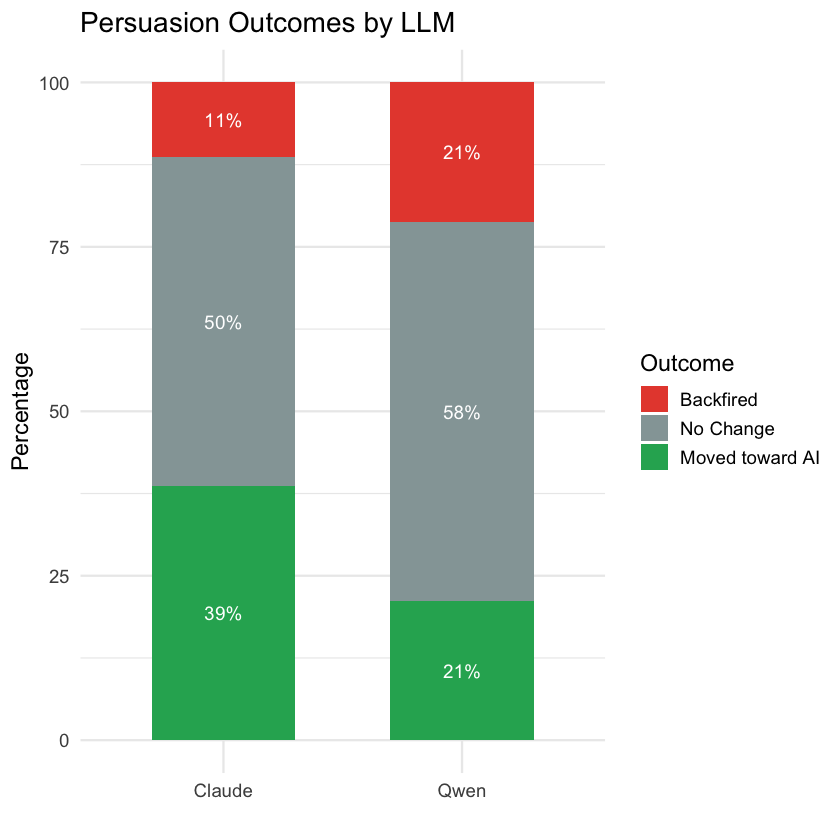

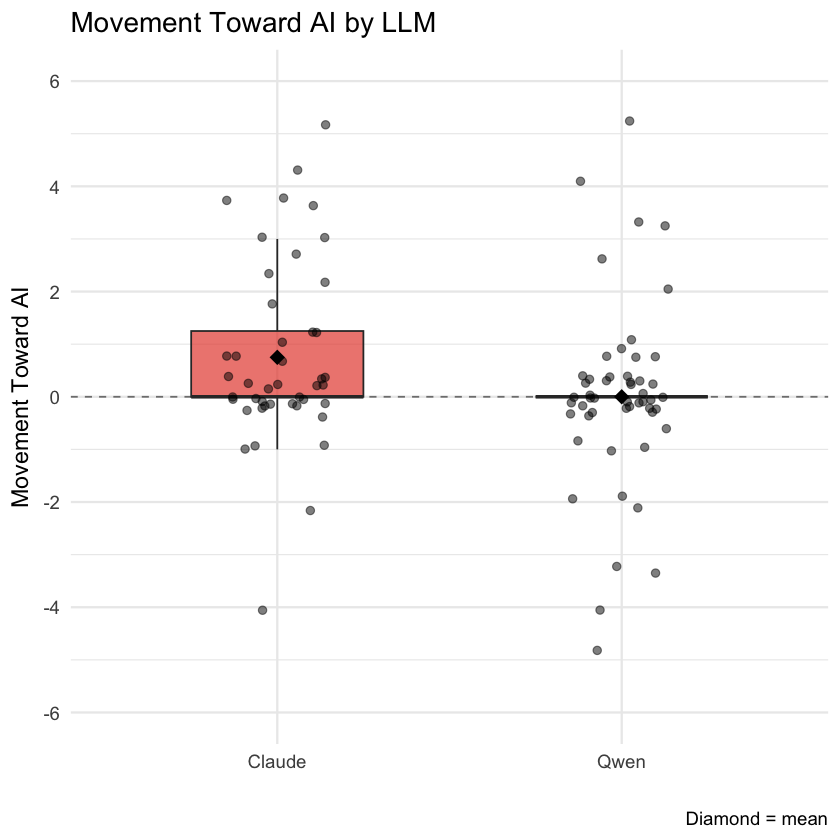

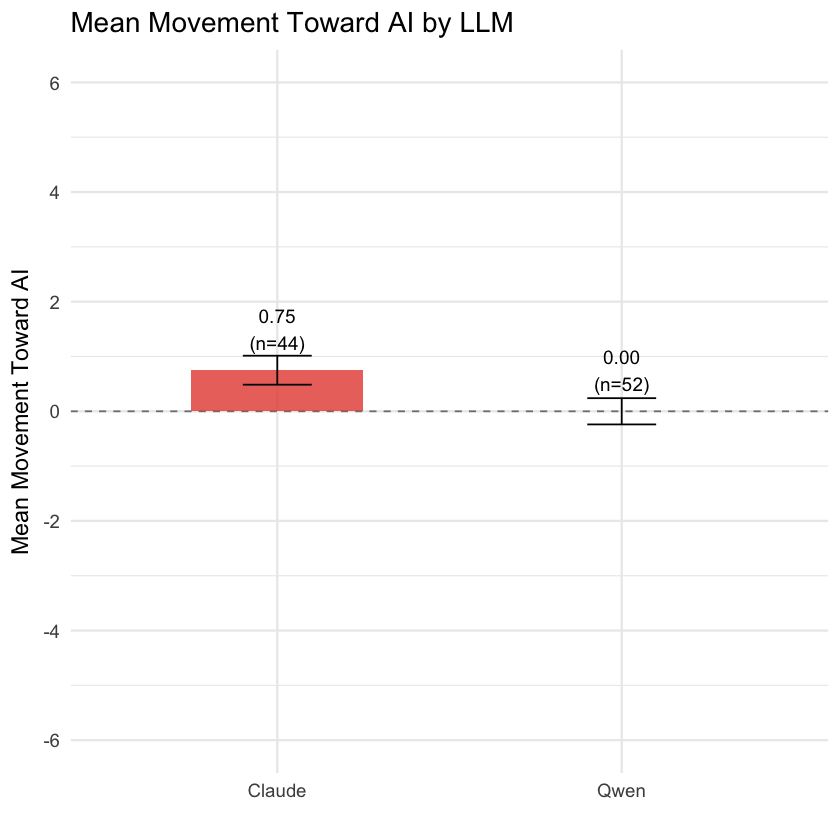

In [16]:
message("\n=== LLM COMPARISON: Claude vs Qwen ===")

llm_data <- data_chat_analysis %>%
mutate(
  llm_label = ifelse(llm_provider == "anthropic", "Claude", "Qwen"),
  llm_label = factor(llm_label, levels = c("Claude", "Qwen")),
  movement_toward_ai = case_when(
    outcome == "Moved toward AI" ~ abs(rating_change),
    outcome == "Backfired" ~ -abs(rating_change),
    TRUE ~ 0
  ),
  outcome = factor(outcome, levels = c("Backfired", "No Change", "Moved toward AI"))
)

# Summary stats 
llm_stats <- llm_data %>%
group_by(llm_label) %>%
summarise(
  n = n(),
  mean_movement = mean(movement_toward_ai),
  median_movement = median(movement_toward_ai),
  sd_movement = sd(movement_toward_ai),
  se_movement = sd_movement / sqrt(n),
  .groups = "drop"
)
message("Summary:")
print(llm_stats)

# Between-group comparison 
claude_data <- llm_data %>% filter(llm_label == "Claude") %>% pull(movement_toward_ai)
qwen_data <- llm_data %>% filter(llm_label == "Qwen") %>% pull(movement_toward_ai)

wilcox_res <- wilcox.test(claude_data, qwen_data, exact = FALSE)
message(sprintf("\nClaude vs Qwen: mean=%.2f vs %.2f, W=%.0f, p=%.4f %s",
              mean(claude_data), mean(qwen_data),
              wilcox_res$statistic, wilcox_res$p.value,
              ifelse(wilcox_res$p.value < 0.05, "*", "")))

# One-sample tests against 0 
message("\nOne-sample tests (H0: mean = 0):")
for (llm in c("Claude", "Qwen")) {
llm_movement <- llm_data %>%
  filter(llm_label == llm) %>%
  pull(movement_toward_ai)

onesample_res <- wilcox.test(llm_movement, mu = 0, exact = FALSE)
message(sprintf("  %s: mean=%.2f, V=%.0f, p=%.4f %s",
                llm, mean(llm_movement),
                onesample_res$statistic, onesample_res$p.value,
                ifelse(onesample_res$p.value < 0.05, "*", "")))
}

# Binomial tests - USE llm_data
message("\nBinomial tests (H0: p=0.5, among those who changed):")
for (llm in c("Claude", "Qwen")) {
llm_changed <- llm_data %>%
  filter(llm_label == llm, outcome %in% c("Moved toward AI", "Backfired"))
n_moved <- sum(llm_changed$outcome == "Moved toward AI")
n_total <- nrow(llm_changed)
if (n_total > 0) {
  binom_res <- binom.test(n_moved, n_total, p = 0.5, alternative = "greater")
  message(sprintf("  %s: %d/%d (%.1f%%), p=%.4f %s",
                  llm, n_moved, n_total, 100 * n_moved / n_total,
                  binom_res$p.value, ifelse(binom_res$p.value < 0.05, "*", "")))
   }
  }


# 1. Stacked bar chart
outcome_pct_llm <- llm_data %>%
count(llm_label, outcome) %>%
group_by(llm_label) %>%
mutate(pct = n / sum(n) * 100) %>%
ungroup()

ggplot(outcome_pct_llm, aes(x = llm_label, y = pct, fill = outcome)) +
geom_col(position = "stack", width = 0.6) +
geom_text(aes(label = ifelse(pct >= 5, sprintf("%.0f%%", pct), "")),
  position = position_stack(vjust = 0.5), size = 4, color = "white") +
scale_fill_manual(values = c("Backfired" = "#E74C3C", "No Change" = "#95A5A6", "Moved toward AI" = "#27AE60")) +
labs(title = "Persuasion Outcomes by LLM", x = "", y = "Percentage", fill = "Outcome") +
theme_minimal(base_size = 14) +
theme(legend.position = "right")

# 2. Boxplot
ggplot(llm_data, aes(x = llm_label, y = movement_toward_ai, fill = llm_label)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_boxplot(width = 0.5, alpha = 0.7, outlier.shape = NA) +
geom_jitter(width = 0.15, alpha = 0.5, size = 2) +
stat_summary(fun = mean, geom = "point", shape = 18, size = 4, color = "black") +
scale_fill_manual(values = c("Claude" = "#E74C3C", "Qwen" = "#3498DB")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Movement Toward AI by LLM", x = "", y = "Movement Toward AI",
caption = "Diamond = mean") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")

# 3. Mean bar chart
ggplot(llm_stats, aes(x = llm_label, y = mean_movement, fill = llm_label)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_col(width = 0.5, alpha = 0.8) +
geom_errorbar(aes(ymin = mean_movement - se_movement, ymax = mean_movement + se_movement), width = 0.2) +
geom_text(aes(label = sprintf("%.2f\n(n=%d)", mean_movement, n)),
  vjust = ifelse(llm_stats$mean_movement >= 0, -0.5, 1.5), size = 4) +
scale_fill_manual(values = c("Claude" = "#E74C3C", "Qwen" = "#3498DB")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Mean Movement Toward AI by LLM", x = "", y = "Mean Movement Toward AI") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")


=== STANCE × LLM INTERACTION ===

Summary:



# A tibble: 4 × 7
  stance_label llm_label     n mean_movement median_movement sd_movement
  <fct>        <fct>     <int>         <dbl>           <dbl>       <dbl>
1 Opposing     Claude       22        1.59                 1        1.84
2 Opposing     Qwen         26        0.423                0        1.72
3 Reinforcing  Claude       22       -0.0909               0        1.19
4 Reinforcing  Qwen         26       -0.423                0        1.65
# ℹ 1 more variable: se_movement <dbl>



Overall: Kruskal-Wallis H=13.90, p=0.0030 *


Claude vs Qwen (by Stance):

  Opposing: mean=1.59 vs 0.42, W=384, p=0.0343 *

  Reinforcing: mean=-0.09 vs -0.42, W=324, p=0.3781 


Opposing vs Reinforcing (by LLM):

  Claude: mean=1.59 vs -0.09, W=354, p=0.0049 *

  Qwen: mean=0.42 vs -0.42, W=408, p=0.1537 



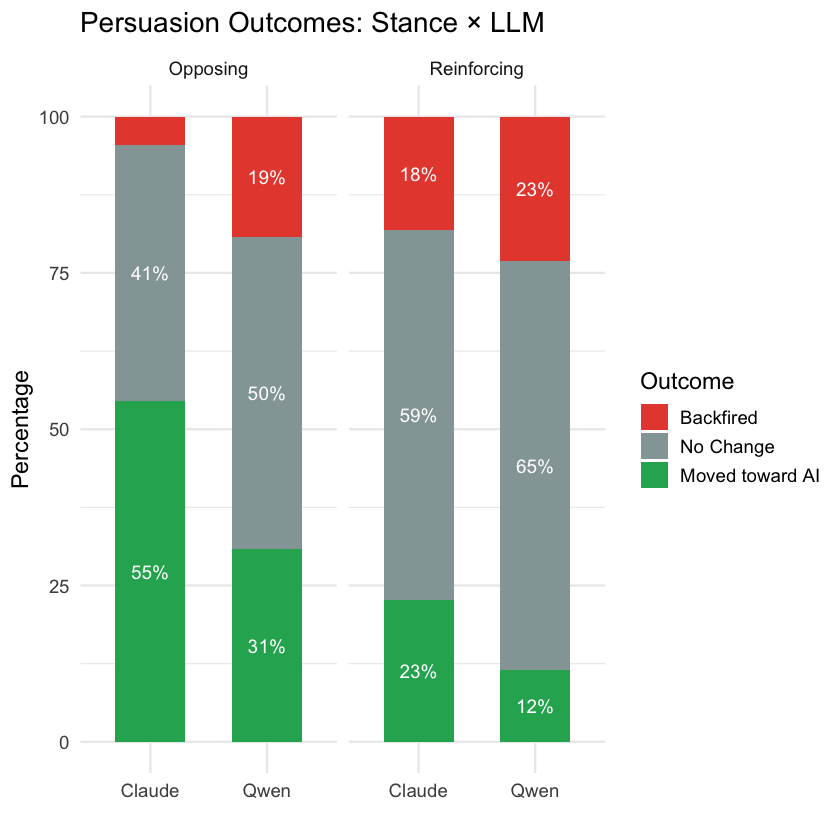

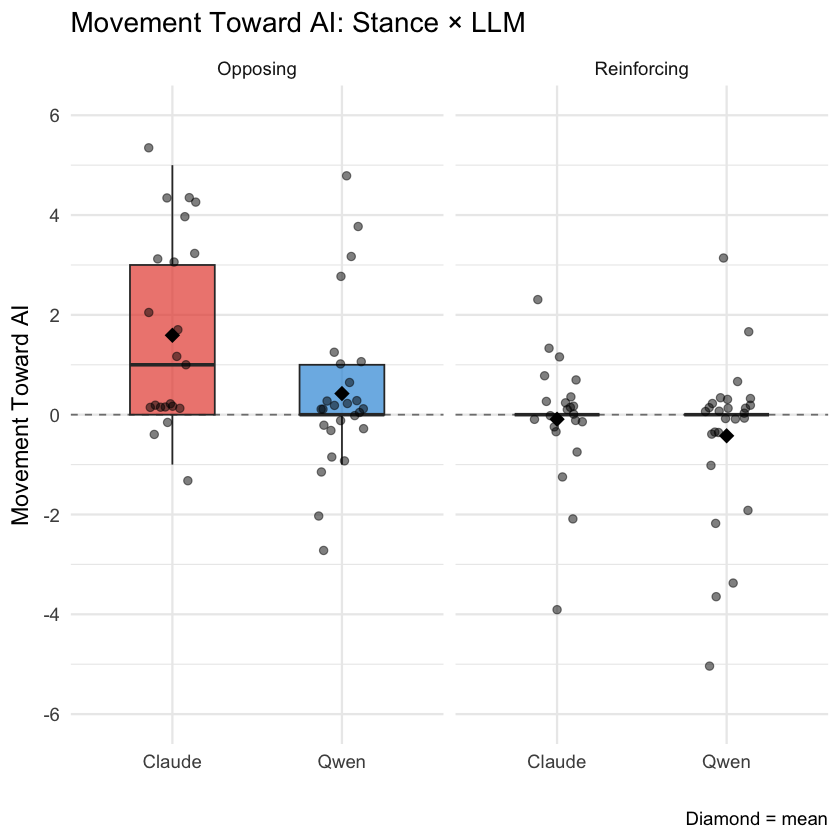

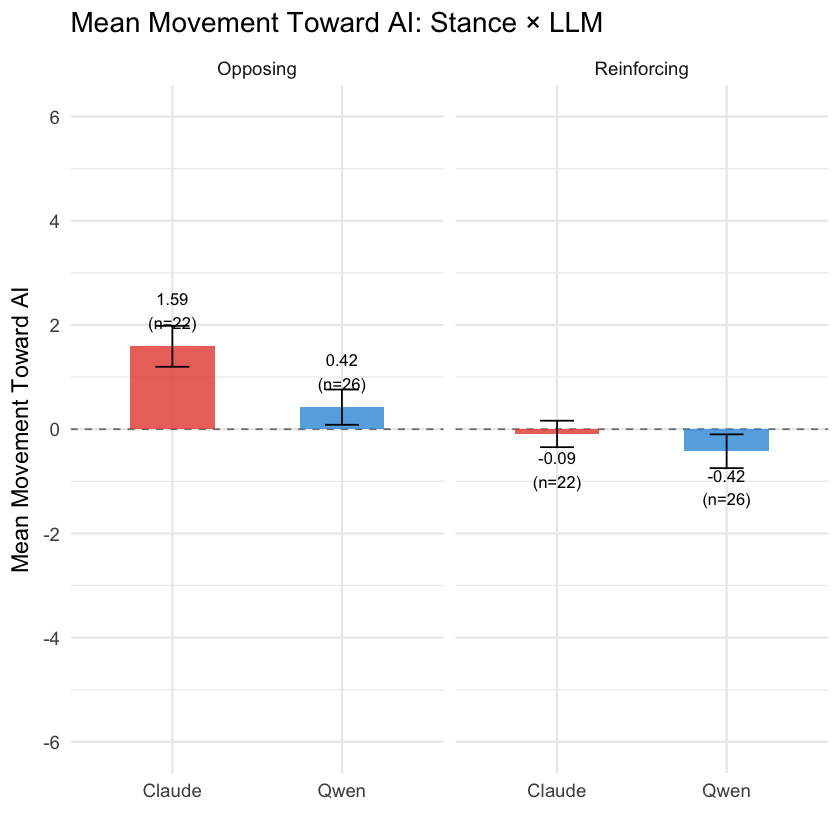

In [17]:
message("\n=== STANCE × LLM INTERACTION ===")

stance_llm_data <- data_chat_analysis %>%
filter(stance_label %in% c("Opposing", "Reinforcing")) %>%
mutate(
  llm_label = ifelse(llm_provider == "anthropic", "Claude", "Qwen"),
  llm_label = factor(llm_label, levels = c("Claude", "Qwen")),
  stance_label = factor(stance_label, levels = c("Opposing", "Reinforcing")),
  movement_toward_ai = case_when(
    outcome == "Moved toward AI" ~ abs(rating_change),
    outcome == "Backfired" ~ -abs(rating_change),
    TRUE ~ 0
  ),
  outcome = factor(outcome, levels = c("Backfired", "No Change", "Moved toward AI")),
  group = paste(stance_label, llm_label, sep = " × ")
)

# Summary stats
stance_llm_stats <- stance_llm_data %>%
group_by(stance_label, llm_label) %>%
summarise(
  n = n(),
  mean_movement = mean(movement_toward_ai),
  median_movement = median(movement_toward_ai),
  sd_movement = sd(movement_toward_ai),
  se_movement = sd_movement / sqrt(n),
  .groups = "drop"
)

message("Summary:")
print(stance_llm_stats)

# Kruskal-Wallis (all 4 groups)
kruskal_res <- kruskal.test(movement_toward_ai ~ group, data = stance_llm_data)
message(sprintf("\nOverall: Kruskal-Wallis H=%.2f, p=%.4f %s",
              kruskal_res$statistic, kruskal_res$p.value,
              ifelse(kruskal_res$p.value < 0.05, "*", "")))

# Claude vs Qwen (by Stance)
message("\nClaude vs Qwen (by Stance):")
for (s in c("Opposing", "Reinforcing")) {
claude_movement <- stance_llm_data %>% filter(stance_label == s, llm_label == "Claude") %>% pull(movement_toward_ai)
qwen_movement <- stance_llm_data %>% filter(stance_label == s, llm_label == "Qwen") %>% pull(movement_toward_ai)

if (length(claude_movement) >= 2 && length(qwen_movement) >= 2) {
  wilcox_res <- wilcox.test(claude_movement, qwen_movement, exact = FALSE)
  message(sprintf("  %s: mean=%.2f vs %.2f, W=%.0f, p=%.4f %s",
                  s, mean(claude_movement), mean(qwen_movement),
                  wilcox_res$statistic, wilcox_res$p.value,
                  ifelse(wilcox_res$p.value < 0.05, "*", "")))
}
}

# Opposing vs Reinforcing (by LLM)
message("\nOpposing vs Reinforcing (by LLM):")
for (llm in c("Claude", "Qwen")) {
opposing_movement <- stance_llm_data %>% filter(llm_label == llm, stance_label == "Opposing") %>% pull(movement_toward_ai)
reinforcing_movement <- stance_llm_data %>% filter(llm_label == llm, stance_label == "Reinforcing") %>% pull(movement_toward_ai)

if (length(opposing_movement) >= 2 && length(reinforcing_movement) >= 2) {
  wilcox_res <- wilcox.test(opposing_movement, reinforcing_movement, exact = FALSE)
  message(sprintf("  %s: mean=%.2f vs %.2f, W=%.0f, p=%.4f %s",
                  llm, mean(opposing_movement), mean(reinforcing_movement),
                  wilcox_res$statistic, wilcox_res$p.value,
                  ifelse(wilcox_res$p.value < 0.05, "*", "")))
}
}

# 1. Stacked bar chart
outcome_pct_stance_llm <- stance_llm_data %>%
count(llm_label, stance_label, outcome) %>%
group_by(llm_label, stance_label) %>%
mutate(pct = n / sum(n) * 100) %>%
ungroup()

ggplot(outcome_pct_stance_llm, aes(x = llm_label, y = pct, fill = outcome)) +
geom_col(position = "stack", width = 0.6) +
geom_text(aes(label = ifelse(pct >= 5, sprintf("%.0f%%", pct), "")),
          position = position_stack(vjust = 0.5), size = 4, color = "white") +
facet_wrap(~ stance_label) +
scale_fill_manual(values = c("Backfired" = "#E74C3C", "No Change" = "#95A5A6", "Moved toward AI" = "#27AE60")) +
labs(title = "Persuasion Outcomes: Stance × LLM", x = "", y = "Percentage", fill = "Outcome") +
theme_minimal(base_size = 14) +
theme(legend.position = "right")

# 2. Boxplot
ggplot(stance_llm_data, aes(x = llm_label, y = movement_toward_ai, fill = llm_label)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_boxplot(width = 0.5, alpha = 0.7, outlier.shape = NA) +
geom_jitter(width = 0.15, alpha = 0.5, size = 2) +
stat_summary(fun = mean, geom = "point", shape = 18, size = 4, color = "black") +
facet_wrap(~ stance_label) +
scale_fill_manual(values = c("Claude" = "#E74C3C", "Qwen" = "#3498DB")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Movement Toward AI: Stance × LLM", x = "", y = "Movement Toward AI",
     caption = "Diamond = mean") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")

# 3. Mean bar chart
ggplot(stance_llm_stats, aes(x = llm_label, y = mean_movement, fill = llm_label)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_col(width = 0.5, alpha = 0.8) +
geom_errorbar(aes(ymin = mean_movement - se_movement, ymax = mean_movement + se_movement), width = 0.2) +
geom_text(aes(label = sprintf("%.2f\n(n=%d)", mean_movement, n)),
          vjust = ifelse(stance_llm_stats$mean_movement >= 0, -0.5, 1.5), size = 3.5) +
facet_wrap(~ stance_label) +
scale_fill_manual(values = c("Claude" = "#E74C3C", "Qwen" = "#3498DB")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Mean Movement Toward AI: Stance × LLM", x = "", y = "Mean Movement Toward AI") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")



=== LLM × CONDITION TYPE ===

Summary:



# A tibble: 6 × 7
  llm_label condition_type       n mean_movement median_movement sd_movement
  <fct>     <fct>            <int>         <dbl>           <dbl>       <dbl>
1 Claude    Control             12        0.25                 0       1.22 
2 Claude    Non-personalized     4        1.5                  1       1.91 
3 Claude    Personalized        28        0.857                0       1.92 
4 Qwen      Control             12       -0.0833               0       1.62 
5 Qwen      Non-personalized    12        0.0833               0       0.515
6 Qwen      Personalized        28        0                    0       2.11 
# ℹ 1 more variable: se_movement <dbl>



Overall: Kruskal-Wallis H=7.30, p=0.1991 


Condition comparisons (by LLM):


Claude (Kruskal-Wallis): H=2.77, p=0.2504 

  Control vs Non-personalized: mean=0.25 vs 1.50, W=14, p=0.1933 

  Control vs Personalized: mean=0.25 vs 0.86, W=123, p=0.1593 

  Non-personalized vs Personalized: mean=1.50 vs 0.86, W=65, p=0.6035 


Qwen (Kruskal-Wallis): H=0.28, p=0.8711 

  Control vs Non-personalized: mean=-0.08 vs 0.08, W=64, p=0.6053 

  Control vs Personalized: mean=-0.08 vs 0.00, W=160, p=0.7983 

  Non-personalized vs Personalized: mean=0.08 vs 0.00, W=178, p=0.7598 


Claude vs Qwen (by Condition):

  Control: mean=0.25 vs -0.08, W=80, p=0.6691 

  Non-personalized: mean=1.50 vs 0.08, W=35, p=0.1212 

  Personalized: mean=0.86 vs 0.00, W=498, p=0.0610 



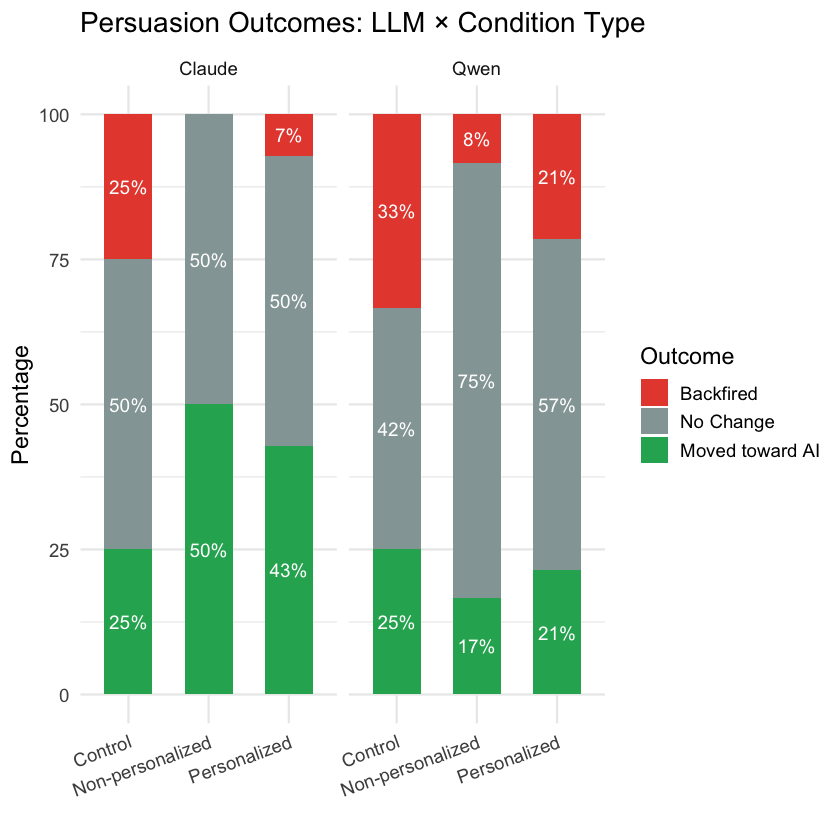

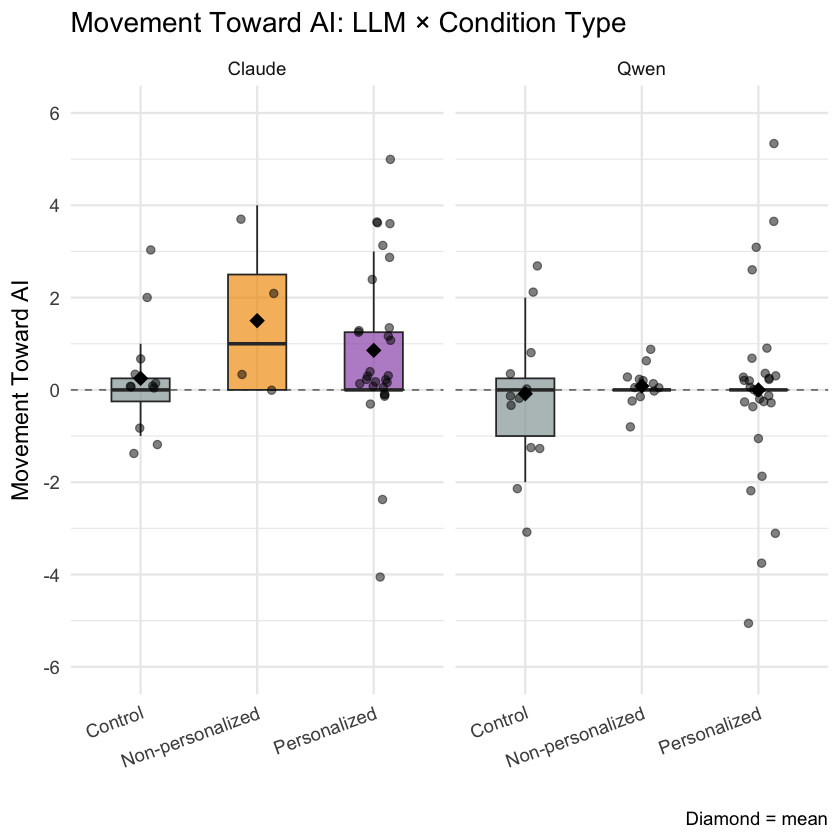

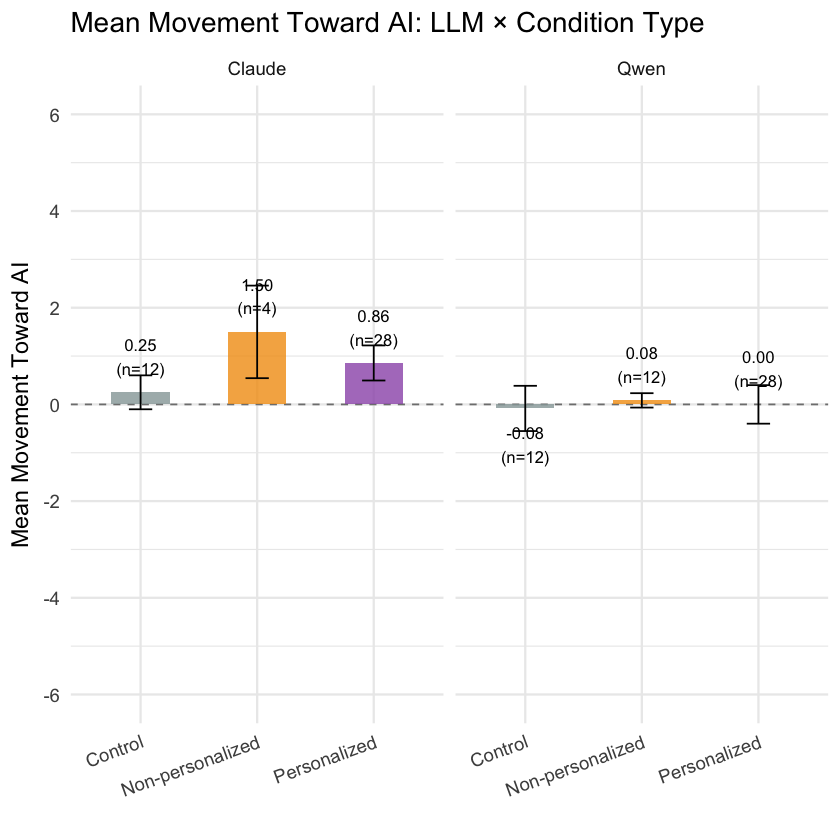

In [18]:
message("\n=== LLM × CONDITION TYPE ===")

llm_condition_data <- data_chat_analysis %>%
mutate(
  llm_label = ifelse(llm_provider == "anthropic", "Claude", "Qwen"),
  llm_label = factor(llm_label, levels = c("Claude", "Qwen")),

  condition_type = case_when(
    condition %in% c("neutral", "Control") ~ "Control",
    condition == "persuade" ~ "Non-personalized",
    condition %in% c("persuade_demo", "persuade_info") ~ "Personalized",
    TRUE ~ NA_character_
  ),
  condition_type = factor(condition_type, levels = c("Control", "Non-personalized", "Personalized")),

  movement_toward_ai = case_when(
    outcome == "Moved toward AI" ~ abs(rating_change),
    outcome == "Backfired" ~ -abs(rating_change),
    TRUE ~ 0
  ),
  outcome = factor(outcome, levels = c("Backfired", "No Change", "Moved toward AI")),
  group = paste(llm_label, condition_type, sep = " × ")
) %>%
filter(!is.na(condition_type))

# Summary stats
llm_condition_stats <- llm_condition_data %>%
group_by(llm_label, condition_type) %>%
summarise(
  n = n(),
  mean_movement = mean(movement_toward_ai),
  median_movement = median(movement_toward_ai),
  sd_movement = sd(movement_toward_ai),
  se_movement = sd_movement / sqrt(n),
  .groups = "drop"
)

message("Summary:")
print(llm_condition_stats)

# Overall Kruskal-Wallis (all 6 groups)
kruskal_all <- kruskal.test(movement_toward_ai ~ group, data = llm_condition_data)
message(sprintf("\nOverall: Kruskal-Wallis H=%.2f, p=%.4f %s",
              kruskal_all$statistic, kruskal_all$p.value,
              ifelse(kruskal_all$p.value < 0.05, "*", "")))

# Condition comparisons within each LLM
message("\nCondition comparisons (by LLM):")
for (llm in c("Claude", "Qwen")) {
llm_data <- llm_condition_data %>% filter(llm_label == llm)

kruskal_res <- kruskal.test(movement_toward_ai ~ condition_type, data = llm_data)
message(sprintf("\n%s (Kruskal-Wallis): H=%.2f, p=%.4f %s",
                llm, kruskal_res$statistic, kruskal_res$p.value,
                ifelse(kruskal_res$p.value < 0.05, "*", "")))

# Pairwise
conditions <- c("Control", "Non-personalized", "Personalized")
for (i in 1:(length(conditions)-1)) {
  for (j in (i+1):length(conditions)) {
    c1 <- conditions[i]
    c2 <- conditions[j]
    data1 <- llm_data %>% filter(condition_type == c1) %>% pull(movement_toward_ai)
    data2 <- llm_data %>% filter(condition_type == c2) %>% pull(movement_toward_ai)

    if (length(data1) >= 2 && length(data2) >= 2) {
      wilcox_res <- wilcox.test(data1, data2, exact = FALSE)
      message(sprintf("  %s vs %s: mean=%.2f vs %.2f, W=%.0f, p=%.4f %s",
                      c1, c2, mean(data1), mean(data2),
                      wilcox_res$statistic, wilcox_res$p.value,
                      ifelse(wilcox_res$p.value < 0.05, "*", "")))
    }
  }
}
}

# LLM comparisons within each condition
message("\nClaude vs Qwen (by Condition):")
for (cond in c("Control", "Non-personalized", "Personalized")) {
claude_data <- llm_condition_data %>% filter(llm_label == "Claude", condition_type == cond) %>% pull(movement_toward_ai)
qwen_data <- llm_condition_data %>% filter(llm_label == "Qwen", condition_type == cond) %>% pull(movement_toward_ai)

if (length(claude_data) >= 2 && length(qwen_data) >= 2) {
  wilcox_res <- wilcox.test(claude_data, qwen_data, exact = FALSE)
  message(sprintf("  %s: mean=%.2f vs %.2f, W=%.0f, p=%.4f %s",
                  cond, mean(claude_data), mean(qwen_data),
                  wilcox_res$statistic, wilcox_res$p.value,
                  ifelse(wilcox_res$p.value < 0.05, "*", "")))
}
}

# 1. Stacked bar chart
outcome_pct_llm_cond <- llm_condition_data %>%
count(llm_label, condition_type, outcome) %>%
group_by(llm_label, condition_type) %>%
mutate(pct = n / sum(n) * 100) %>%
ungroup()

ggplot(outcome_pct_llm_cond, aes(x = condition_type, y = pct, fill = outcome)) +
geom_col(position = "stack", width = 0.6) +
geom_text(aes(label = ifelse(pct >= 5, sprintf("%.0f%%", pct), "")),
          position = position_stack(vjust = 0.5), size = 4, color = "white") +
facet_wrap(~ llm_label) +
scale_fill_manual(values = c("Backfired" = "#E74C3C", "No Change" = "#95A5A6", "Moved toward AI" = "#27AE60")) +
labs(title = "Persuasion Outcomes: LLM × Condition Type", x = "", y = "Percentage", fill = "Outcome") +
theme_minimal(base_size = 14) +
theme(legend.position = "right", axis.text.x = element_text(angle = 20, hjust = 1))

# 2. Boxplot
ggplot(llm_condition_data, aes(x = condition_type, y = movement_toward_ai, fill = condition_type)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_boxplot(width = 0.5, alpha = 0.7, outlier.shape = NA) +
geom_jitter(width = 0.15, alpha = 0.5, size = 2) +
stat_summary(fun = mean, geom = "point", shape = 18, size = 4, color = "black") +
facet_wrap(~ llm_label) +
scale_fill_manual(values = c("Control" = "#95A5A6", "Non-personalized" = "#F39C12", "Personalized" = "#9B59B6")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Movement Toward AI: LLM × Condition Type", x = "", y = "Movement Toward AI",
     caption = "Diamond = mean") +
theme_minimal(base_size = 14) +
theme(legend.position = "none", axis.text.x = element_text(angle = 20, hjust = 1))

# 3. Mean bar chart
ggplot(llm_condition_stats, aes(x = condition_type, y = mean_movement, fill = condition_type)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_col(width = 0.5, alpha = 0.8) +
geom_errorbar(aes(ymin = mean_movement - se_movement, ymax = mean_movement + se_movement), width = 0.2) +
geom_text(aes(label = sprintf("%.2f\n(n=%d)", mean_movement, n)),
          vjust = ifelse(llm_condition_stats$mean_movement >= 0, -0.5, 1.5), size = 3.5) +
facet_wrap(~ llm_label) +
scale_fill_manual(values = c("Control" = "#95A5A6", "Non-personalized" = "#F39C12", "Personalized" = "#9B59B6")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Mean Movement Toward AI: LLM × Condition Type", x = "", y = "Mean Movement Toward AI") +
theme_minimal(base_size = 14) +
theme(legend.position = "none", axis.text.x = element_text(angle = 20, hjust = 1))



=== LLM × CONDITION (Control vs Persuasion) ===

Summary:



# A tibble: 4 × 7
  llm_label condition_group     n mean_movement median_movement sd_movement
  <fct>     <fct>           <int>         <dbl>           <dbl>       <dbl>
1 Claude    Control            12        0.25                 0        1.22
2 Claude    Persuasion         32        0.938                0        1.90
3 Qwen      Control            12       -0.0833               0        1.62
4 Qwen      Persuasion         40        0.0250               0        1.78
# ℹ 1 more variable: se_movement <dbl>



Overall: Kruskal-Wallis H=6.97, p=0.0728 


Control vs Persuasion (by LLM):

  Claude: mean=0.25 vs 0.94, W=136, p=0.1205 

  Qwen: mean=-0.08 vs 0.02, W=223, p=0.6899 


Claude vs Qwen (by Condition):

  Control: mean=0.25 vs -0.08, W=80, p=0.6691 

  Persuasion: mean=0.94 vs 0.02, W=827, p=0.0191 *



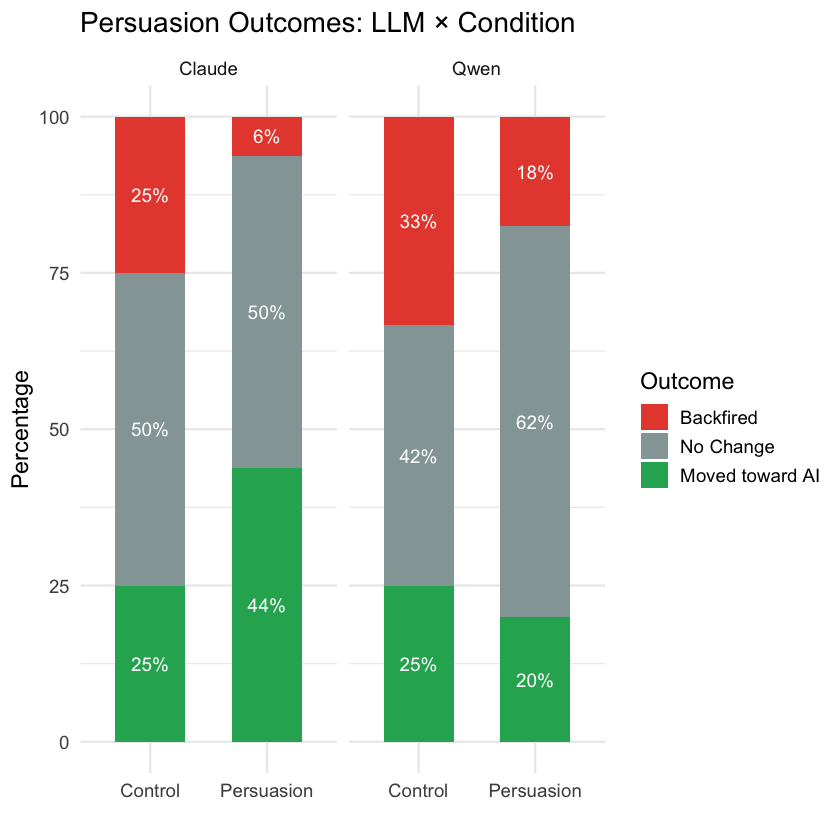

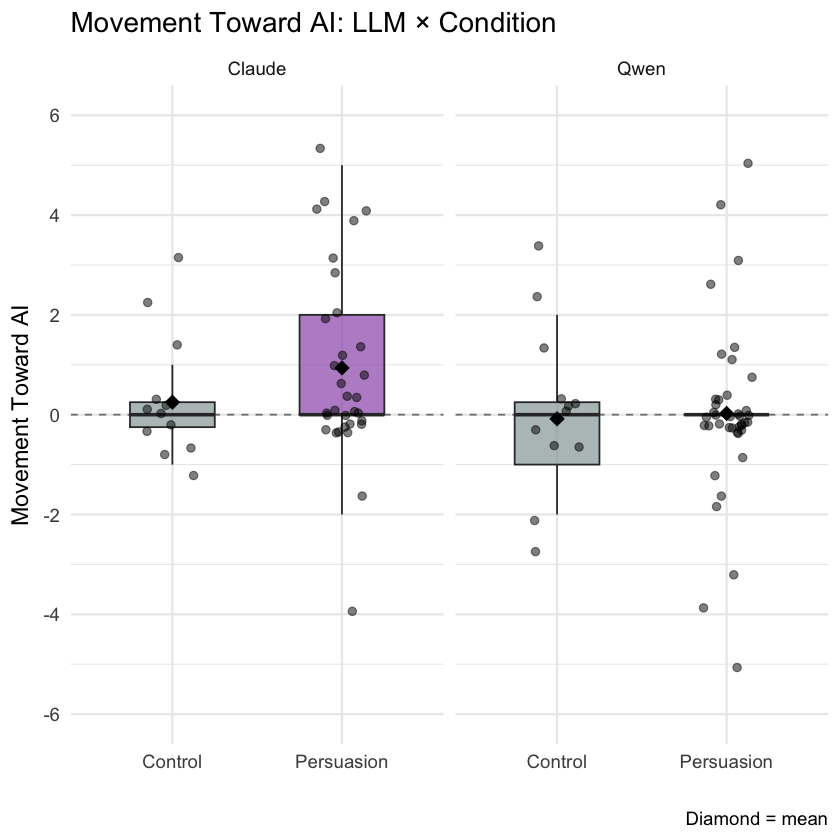

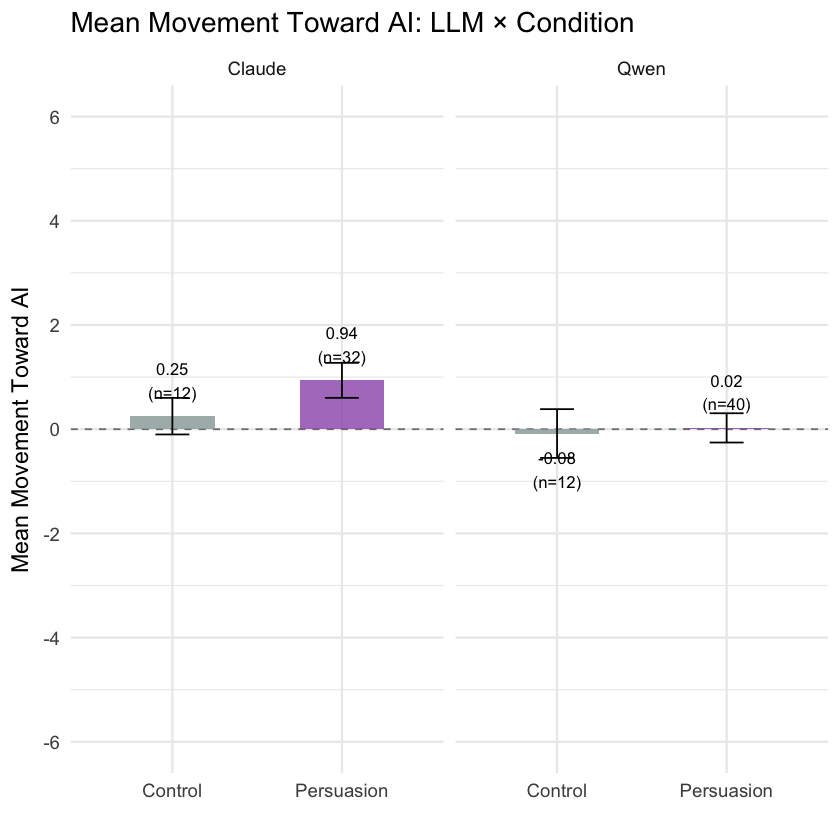

In [19]:
message("\n=== LLM × CONDITION (Control vs Persuasion) ===")

llm_cond_data <- data_chat_analysis %>%
mutate(
  llm_label = ifelse(llm_provider == "anthropic", "Claude", "Qwen"),
  llm_label = factor(llm_label, levels = c("Claude", "Qwen")),
  condition_group = case_when(
    condition %in% c("neutral", "Control") ~ "Control",
    condition %in% c("persuade", "persuade_demo", "persuade_info") ~ "Persuasion",
    TRUE ~ NA_character_
  ),
  condition_group = factor(condition_group, levels = c("Control", "Persuasion")),
  movement_toward_ai = case_when(
    outcome == "Moved toward AI" ~ abs(rating_change),
    outcome == "Backfired" ~ -abs(rating_change),
    TRUE ~ 0
  ),
  outcome = factor(outcome, levels = c("Backfired", "No Change", "Moved toward AI")),
  group = paste(llm_label, condition_group, sep = " × ")
) %>%
filter(!is.na(condition_group))

# Summary stats
llm_cond_stats <- llm_cond_data %>%
group_by(llm_label, condition_group) %>%
summarise(
  n = n(),
  mean_movement = mean(movement_toward_ai),
  median_movement = median(movement_toward_ai),
  sd_movement = sd(movement_toward_ai),
  se_movement = sd_movement / sqrt(n),
  .groups = "drop"
)

message("Summary:")
print(llm_cond_stats)

# Overall Kruskal-Wallis (all 4 groups)
kruskal_all <- kruskal.test(movement_toward_ai ~ group, data = llm_cond_data)
message(sprintf("\nOverall: Kruskal-Wallis H=%.2f, p=%.4f %s",
              kruskal_all$statistic, kruskal_all$p.value,
              ifelse(kruskal_all$p.value < 0.05, "*", "")))

# Control vs Persuasion (by LLM)
message("\nControl vs Persuasion (by LLM):")
for (llm in c("Claude", "Qwen")) {
control_movement <- llm_cond_data %>% filter(llm_label == llm, condition_group == "Control") %>% pull(movement_toward_ai)
persuasion_movement <- llm_cond_data %>% filter(llm_label == llm, condition_group == "Persuasion") %>% pull(movement_toward_ai)

if (length(control_movement) >= 2 && length(persuasion_movement) >= 2) {
  wilcox_res <- wilcox.test(control_movement, persuasion_movement, exact = FALSE)
  message(sprintf("  %s: mean=%.2f vs %.2f, W=%.0f, p=%.4f %s",
                  llm, mean(control_movement), mean(persuasion_movement),
                  wilcox_res$statistic, wilcox_res$p.value,
                  ifelse(wilcox_res$p.value < 0.05, "*", "")))
}
}

# Claude vs Qwen (by Condition)
message("\nClaude vs Qwen (by Condition):")
for (cond in c("Control", "Persuasion")) {
claude_movement <- llm_cond_data %>% filter(llm_label == "Claude", condition_group == cond) %>% pull(movement_toward_ai)
qwen_movement <- llm_cond_data %>% filter(llm_label == "Qwen", condition_group == cond) %>% pull(movement_toward_ai)

if (length(claude_movement) >= 2 && length(qwen_movement) >= 2) {
  wilcox_res <- wilcox.test(claude_movement, qwen_movement, exact = FALSE)
  message(sprintf("  %s: mean=%.2f vs %.2f, W=%.0f, p=%.4f %s",
                  cond, mean(claude_movement), mean(qwen_movement),
                  wilcox_res$statistic, wilcox_res$p.value,
                  ifelse(wilcox_res$p.value < 0.05, "*", "")))
}
}

# 1. Stacked bar chart
outcome_pct_llm_cond <- llm_cond_data %>%
count(llm_label, condition_group, outcome) %>%
group_by(llm_label, condition_group) %>%
mutate(pct = n / sum(n) * 100) %>%
ungroup()

ggplot(outcome_pct_llm_cond, aes(x = condition_group, y = pct, fill = outcome)) +
geom_col(position = "stack", width = 0.6) +
geom_text(aes(label = ifelse(pct >= 5, sprintf("%.0f%%", pct), "")),
          position = position_stack(vjust = 0.5), size = 4, color = "white") +
facet_wrap(~ llm_label) +
scale_fill_manual(values = c("Backfired" = "#E74C3C", "No Change" = "#95A5A6", "Moved toward AI" = "#27AE60")) +
labs(title = "Persuasion Outcomes: LLM × Condition", x = "", y = "Percentage", fill = "Outcome") +
theme_minimal(base_size = 14) +
theme(legend.position = "right")

# 2. Boxplot
ggplot(llm_cond_data, aes(x = condition_group, y = movement_toward_ai, fill = condition_group)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_boxplot(width = 0.5, alpha = 0.7, outlier.shape = NA) +
geom_jitter(width = 0.15, alpha = 0.5, size = 2) +
stat_summary(fun = mean, geom = "point", shape = 18, size = 4, color = "black") +
facet_wrap(~ llm_label) +
scale_fill_manual(values = c("Control" = "#95A5A6", "Persuasion" = "#9B59B6")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Movement Toward AI: LLM × Condition", x = "", y = "Movement Toward AI",
     caption = "Diamond = mean") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")

# 3. Mean bar chart
ggplot(llm_cond_stats, aes(x = condition_group, y = mean_movement, fill = condition_group)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_col(width = 0.5, alpha = 0.8) +
geom_errorbar(aes(ymin = mean_movement - se_movement, ymax = mean_movement + se_movement), width = 0.2) +
geom_text(aes(label = sprintf("%.2f\n(n=%d)", mean_movement, n)),
          vjust = ifelse(llm_cond_stats$mean_movement >= 0, -0.5, 1.5), size = 3.5) +
facet_wrap(~ llm_label) +
scale_fill_manual(values = c("Control" = "#95A5A6", "Persuasion" = "#9B59B6")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Mean Movement Toward AI: LLM × Condition", x = "", y = "Mean Movement Toward AI") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")



=== PER LLM × PER CONDITION ===

Summary:



# A tibble: 8 × 7
  llm_label condition_label     n mean_movement median_movement sd_movement
  <fct>     <fct>           <int>         <dbl>           <dbl>       <dbl>
1 Claude    Control            12        0.25                 0       1.22 
2 Claude    Persuade            4        1.5                  1       1.91 
3 Claude    Demo               12        0.667                0       0.985
4 Claude    Info               16        1                    0       2.42 
5 Qwen      Control            12       -0.0833               0       1.62 
6 Qwen      Persuade           12        0.0833               0       0.515
7 Qwen      Demo               12        0.25                 0       2.30 
8 Qwen      Info               16       -0.188                0       2.01 
# ℹ 1 more variable: se_movement <dbl>



Binomial tests (H0: p=0.5, among those who changed):


Claude:

  Control: 3/6 (50.0%), p=0.6562 

  Persuade: 2/2 (100.0%), p=0.2500 

  Demo: 5/5 (100.0%), p=0.0312 *

  Info: 7/9 (77.8%), p=0.0898 


Qwen:

  Control: 3/7 (42.9%), p=0.7734 

  Persuade: 2/3 (66.7%), p=0.5000 

  Demo: 3/5 (60.0%), p=0.5000 

  Info: 3/7 (42.9%), p=0.7734 


Condition comparisons (by LLM):


Claude (Kruskal-Wallis): H=2.80, p=0.4237 


Qwen (Kruskal-Wallis): H=0.67, p=0.8798 


Claude vs Qwen (by Condition):

  Control: mean=0.25 vs -0.08, W=80, p=0.6691 

  Persuade: mean=1.50 vs 0.08, W=35, p=0.1212 

  Demo: mean=0.67 vs 0.25, W=84, p=0.4382 

  Info: mean=1.00 vs -0.19, W=166, p=0.1301 



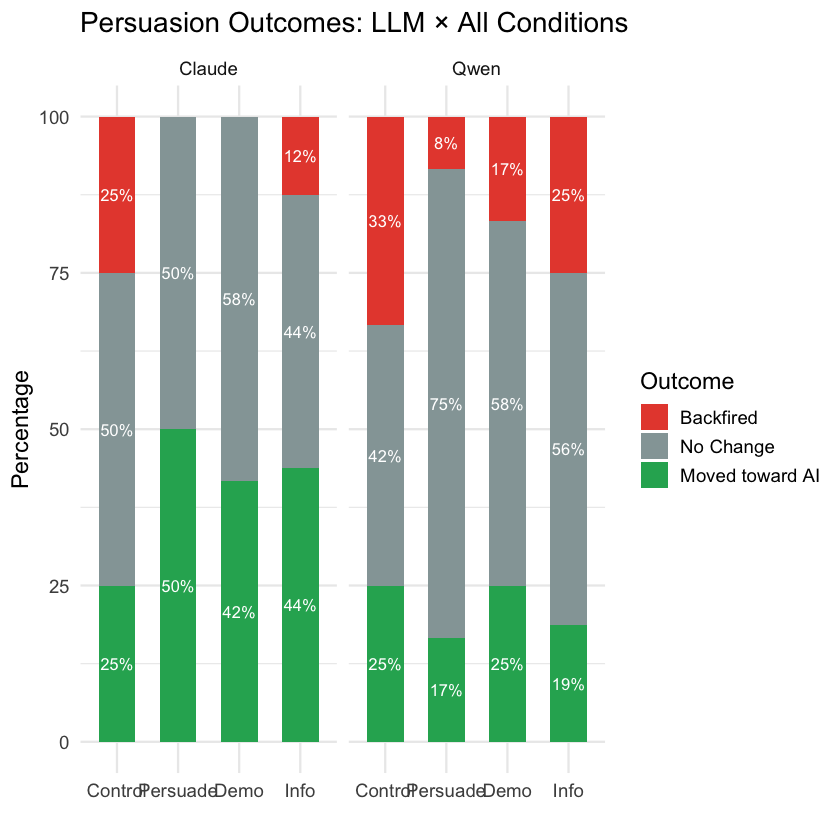

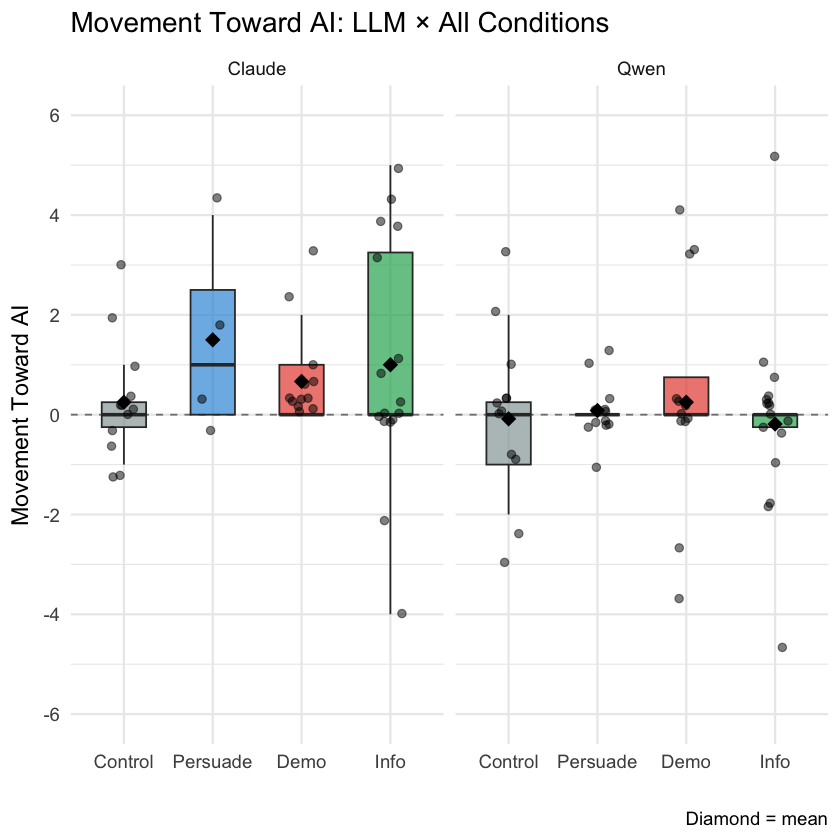

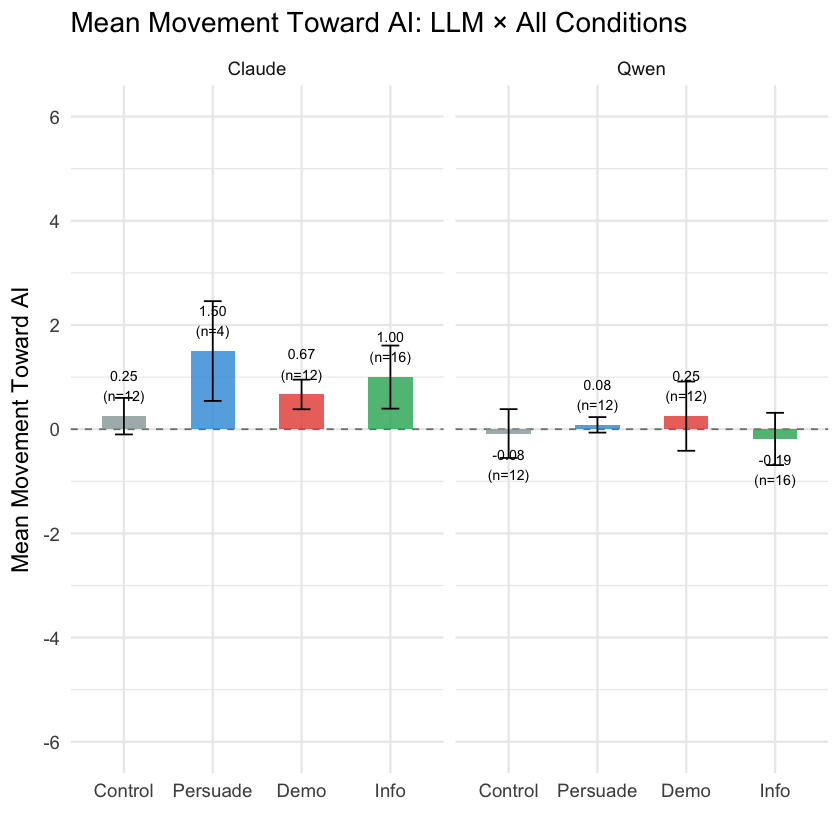

In [20]:
message("\n=== PER LLM × PER CONDITION ===")

llm_all_cond_data <- data_chat_analysis %>%
mutate(
  llm_label = ifelse(llm_provider == "anthropic", "Claude", "Qwen"),
  llm_label = factor(llm_label, levels = c("Claude", "Qwen")),
  condition_label = factor(case_when(
    condition %in% c("neutral", "Control") ~ "Control",
    condition == "persuade" ~ "Persuade",
    condition == "persuade_demo" ~ "Demo",
    condition == "persuade_info" ~ "Info",
    TRUE ~ NA_character_
  ), levels = c("Control", "Persuade", "Demo", "Info")),
  movement_toward_ai = case_when(
    outcome == "Moved toward AI" ~ abs(rating_change),
    outcome == "Backfired" ~ -abs(rating_change),
    TRUE ~ 0
  ),
  outcome = factor(outcome, levels = c("Backfired", "No Change", "Moved toward AI"))
) %>%
filter(!is.na(condition_label))

# Summary stats
llm_all_cond_stats <- llm_all_cond_data %>%
group_by(llm_label, condition_label) %>%
summarise(
  n = n(),
  mean_movement = mean(movement_toward_ai),
  median_movement = median(movement_toward_ai),
  sd_movement = sd(movement_toward_ai),
  se_movement = sd_movement / sqrt(n),
  .groups = "drop"
)

message("Summary:")
print(llm_all_cond_stats)

# Binomial tests per LLM per condition (among those who changed)
message("\nBinomial tests (H0: p=0.5, among those who changed):")
for (llm in c("Claude", "Qwen")) {
message(sprintf("\n%s:", llm))

for (cond in c("Control", "Persuade", "Demo", "Info")) {
  cond_changed <- llm_all_cond_data %>%
    filter(llm_label == llm, condition_label == cond,
           outcome %in% c("Moved toward AI", "Backfired"))

  n_moved <- sum(cond_changed$outcome == "Moved toward AI")
  n_total <- nrow(cond_changed)

  if (n_total >= 2) {
    binom_res <- binom.test(n_moved, n_total, p = 0.5, alternative = "greater")
    message(sprintf("  %s: %d/%d (%.1f%%), p=%.4f %s",
                    cond, n_moved, n_total, n_moved/n_total*100, binom_res$p.value,
                    ifelse(binom_res$p.value < 0.05, "*", "")))
  } else if (n_total > 0) {
    message(sprintf("  %s: %d/%d (too few)", cond, n_moved, n_total))
  } else {
    message(sprintf("  %s: no changes", cond))
  }
}
}

# Condition comparisons within each LLM
message("\nCondition comparisons (by LLM):")
for (llm in c("Claude", "Qwen")) {
llm_data <- llm_all_cond_data %>% filter(llm_label == llm)

kruskal_res <- kruskal.test(movement_toward_ai ~ condition_label, data = llm_data)
message(sprintf("\n%s (Kruskal-Wallis): H=%.2f, p=%.4f %s",
                llm, kruskal_res$statistic, kruskal_res$p.value,
                ifelse(kruskal_res$p.value < 0.05, "*", "")))
}

# Claude vs Qwen (by Condition)
message("\nClaude vs Qwen (by Condition):")
for (cond in c("Control", "Persuade", "Demo", "Info")) {
claude_movement <- llm_all_cond_data %>% filter(llm_label == "Claude", condition_label == cond) %>% pull(movement_toward_ai)
qwen_movement <- llm_all_cond_data %>% filter(llm_label == "Qwen", condition_label == cond) %>% pull(movement_toward_ai)

if (length(claude_movement) >= 2 && length(qwen_movement) >= 2) {
  wilcox_res <- wilcox.test(claude_movement, qwen_movement, exact = FALSE)
  message(sprintf("  %s: mean=%.2f vs %.2f, W=%.0f, p=%.4f %s",
                  cond, mean(claude_movement), mean(qwen_movement),
                  wilcox_res$statistic, wilcox_res$p.value,
                  ifelse(wilcox_res$p.value < 0.05, "*", "")))
} else {
  message(sprintf("  %s: not enough data", cond))
}
}

# 1. Stacked bar chart
outcome_pct_llm_all <- llm_all_cond_data %>%
count(llm_label, condition_label, outcome) %>%
group_by(llm_label, condition_label) %>%
mutate(pct = n / sum(n) * 100) %>%
ungroup()

ggplot(outcome_pct_llm_all, aes(x = condition_label, y = pct, fill = outcome)) +
geom_col(position = "stack", width = 0.6) +
geom_text(aes(label = ifelse(pct >= 5, sprintf("%.0f%%", pct), "")),
          position = position_stack(vjust = 0.5), size = 3.5, color = "white") +
facet_wrap(~ llm_label) +
scale_fill_manual(values = c("Backfired" = "#E74C3C", "No Change" = "#95A5A6", "Moved toward AI" = "#27AE60")) +
labs(title = "Persuasion Outcomes: LLM × All Conditions", x = "", y = "Percentage", fill = "Outcome") +
theme_minimal(base_size = 14) +
theme(legend.position = "right")

# 2. Boxplot
ggplot(llm_all_cond_data, aes(x = condition_label, y = movement_toward_ai, fill = condition_label)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_boxplot(width = 0.5, alpha = 0.7, outlier.shape = NA) +
geom_jitter(width = 0.15, alpha = 0.5, size = 2) +
stat_summary(fun = mean, geom = "point", shape = 18, size = 4, color = "black") +
facet_wrap(~ llm_label) +
scale_fill_manual(values = c("Control" = "#95A5A6", "Persuade" = "#3498DB", "Demo" = "#E74C3C", "Info" = "#27AE60")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Movement Toward AI: LLM × All Conditions", x = "", y = "Movement Toward AI",
     caption = "Diamond = mean") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")

# 3. Mean bar chart
ggplot(llm_all_cond_stats, aes(x = condition_label, y = mean_movement, fill = condition_label)) +
geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
geom_col(width = 0.5, alpha = 0.8) +
geom_errorbar(aes(ymin = mean_movement - se_movement, ymax = mean_movement + se_movement), width = 0.2) +
geom_text(aes(label = sprintf("%.2f\n(n=%d)", mean_movement, n)),
          vjust = ifelse(llm_all_cond_stats$mean_movement >= 0, -0.5, 1.5), size = 3) +
facet_wrap(~ llm_label) +
scale_fill_manual(values = c("Control" = "#95A5A6", "Persuade" = "#3498DB", "Demo" = "#E74C3C", "Info" = "#27AE60")) +
scale_y_continuous(limits = c(-6, 6), breaks = seq(-6, 6, 2)) +
labs(title = "Mean Movement Toward AI: LLM × All Conditions", x = "", y = "Mean Movement Toward AI") +
theme_minimal(base_size = 14) +
theme(legend.position = "none")
